___


# <font color= #8A0829> Proyecto Taller de Modelado de Datos </font>
- <Strong> `Isaac Vazquez Sandoval`, `Crespo Neri, Diego Ubaldo`, `Garibay Zepeda, Julio Andrés` </Strong>
- <Strong> Año </Strong>: 2025
- <Strong> Email: </Strong>  <font color="blue"> `isaac.vazqsand@gmail.com`, `ubaldo.crespo@iteso.mx`, `julio.garibay@iteso.mx` </font>
___




### OBJETIVO: 

El objetivo del proyecto es evaluar el conocimiento adquirido sobre la preparación de datos y construcción de modelos predictivos tanto para problemas de regresión como de clasificación.  Se busca abordar la construcción de los modelos, fundamentar por medio de la comunicación de resultados, evaluación de las predicciones del modelo y la metodología establecida para la preparación de los datos. 

## Entregables:

El proyecto se dividirá en 3 entregables:

### Engrega 1 (Limpieza y anális exploratorio):


#### Regresión

1. **Visualización, exploración, preparación y análisis de datos:** 
- Extracción de información estadística básica en los datos analizados.
- En esta fase las características de las bases de datos deben ser mencionadas (datos nulos, datos sesgados, datos atípicos, distribución de datos, etc.)
- Limpieza de datos
- En esta fase de debe mencionar y mostrar el proceso y decisiones tomadas para procesar y limpiar estos datos. 
- Se deben incluir gráficos interesantes que muestren el comportamiento de los datos y cómo se relacionan, así como acompañar los gráficos con una explicación de lo que se observa en el gráfico.
- Después de haber hecho el análisis de tus datos, puedes irte dando una idea de cuál modelo es el mejor para tu dataset. 
- Explica dadas las caracterícas que observaste sobre los datos que tienes, cuál sería el mejor modelo a aplicar en tu dataset. 


### 1.0 Acerca del Dataset

#### 1.0.1 Origen:

https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-sdss17


#### 1.0.2 Problema a resolver

Este dataset consiste de 100,000 observaciones espaciales por parte del   "SDSS"(Un proyecto del estudio del espacio). Este dataset esta principalmente construido para clasificacion de estrellas, galaxias y quazares dependiendo sus carateristicas, sin embargo nuestro objetivo sera hacer un **analisis de regresion de la variable "redshift"** la cual significa en palabras sencillas: "la longitud de onda de la luz que registramos de los cuerpos celestes", esto es importante porque nos permite saber la distancia y velocidad en la que se acercan o alejan objetos celestes relativos a la tierra, lo cual en ultima instancia nos permite crear mapas de universo para comprender su historia y evolucion. 

#### 1.0.3 Variables del Dataset

- obj_ID = Identificador de Objeto, el valor único que identifica al objeto en el catálogo de imágenes usado por el CAS.

- alpha = Ángulo de Ascensión Recta (en la época J2000).

- delta = Ángulo de Declinación (en la época J2000).

- u = Filtro ultravioleta en el sistema fotométrico.

- g = Filtro verde en el sistema fotométrico.

- r = Filtro rojo en el sistema fotométrico.

- i = Filtro infrarrojo cercano en el sistema fotométrico.

- z = Filtro infrarrojo en el sistema fotométrico.

- run_ID = Número de Corrida (Run Number), usado para identificar el barrido (scan) específico.

- rereun_ID = Número de Reprocesamiento (Rerun Number), para especificar cómo fue procesada la imagen.

- cam_col = Columna de la cámara, para identificar la línea de barrido (scanline) dentro de la corrida.

- field_ID = Número de campo, para identificar cada campo.

- spec_obj_ID = ID único usado para objetos espectroscópicos ópticos (esto significa que 2 observaciones diferentes con el mismo spec_obj_ID deben compartir la clase de salida).

- class = Clase de objeto (objeto galaxia, estrella o cuásar).

- **redshift = Valor de desplazamiento al rojo (redshift), basado en el incremento de la longitud de onda.**

- plate = ID de placa, identifica cada placa en SDSS.

- MJD = Fecha Juliana Modificada, usada para indicar cuándo fue tomado un dato específico de SDSS.

- fiber_ID = ID de fibra, que identifica la fibra que apuntó la luz al plano focal en cada observación.

### 1.1 Importación de Librerías y Carga de Datos 

In [225]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

- ***pandas*** es necesario para cargar el dataset
- ***numpy*** es necesario para realizar calculos con los datos
- ***matplotlib.pyplot*** y ***seaborn*** son necesesarios para visualizar los datos
- ***train_test_split*** es necesesario para separar datos de entrenamiento y prueba
- ***StandardScaler*** es para escalar los datos

In [226]:
df=pd.read_csv('data/regression/redshift.csv')

- Cargamos los datos a partir de un .csv

### 1.2 Análisis Exploratorio de los Datos

#### 1.2.1 Extracción de Datos Estadísticos

In [227]:
print("Primeras 5 filas del DataFrame:")
df.head(5)

Primeras 5 filas del DataFrame:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [228]:
rows, cols = df.shape
print(f'El dataset tiene {rows} filas y {cols} columnas.')

El dataset tiene 100000 filas y 18 columnas.


- Podemos observar 18 propiedades, por pura intuicion podemos entender que todas las que tiene el sufijo: '_ID' no son para nada utiles en el analisis de regresion, ya que son solo etiquetas, seria como intentar predecir el salario de alguien con su numero de seguro social.

In [229]:
print("\nDescripción estadística del dataset:")
df.describe()


Descripción estadística del dataset:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


In [230]:
print("\nInformación del DataFrame:\n")
print(df.info())


Información del DataFrame:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
d

- Como podemos observar, todas nuestras variables son numericas a excepcion de "class"(tipo de galaxia), por lo que seria bueno hacer encoding, para que todos nuestros datos sean numericos

In [231]:
unique_counts = df.nunique()
print("Número de valores únicos por columna:\n")
print(unique_counts)

Número de valores únicos por columna:

obj_ID          78053
alpha           99999
delta           99999
u               93748
g               92651
r               91901
i               92019
z               92007
run_ID            430
rerun_ID            1
cam_col             6
field_ID          856
spec_obj_ID    100000
class               3
redshift        99295
plate            6284
MJD              2180
fiber_ID         1000
dtype: int64


- Vemos que la columnna "rerun_ID" tienen un solo valor, segun mi entendimiento esta variable se trata del tipo de procesamiento de imagen, por lo que podemos inferir que solo se uso un tipo de procesamiento. No tiene ningun valor para nuestro analisis de regresion.

- Tambien esta "cam_col" la cual es informacion tecnica de la camara(que tiene 6 columnas), no esta relacionada para nada con redshift.

In [232]:
print("Datos Nulos: ")
print(df.isnull().sum())

Datos Nulos: 
obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64


- No tenemos ningun valor nulo, esto simplifica nuestra limpieza de datos

Analisis de Sesgo:
obj_ID           0.399
alpha           -0.029
delta            0.175
u             -313.849
g             -314.277
r               -0.508
i               -0.404
z             -314.759
run_ID           0.399
rerun_ID         0.000
cam_col         -0.031
field_ID         1.753
spec_obj_ID      0.198
redshift         2.524
plate            0.198
MJD             -0.382
fiber_ID         0.230
dtype: float64


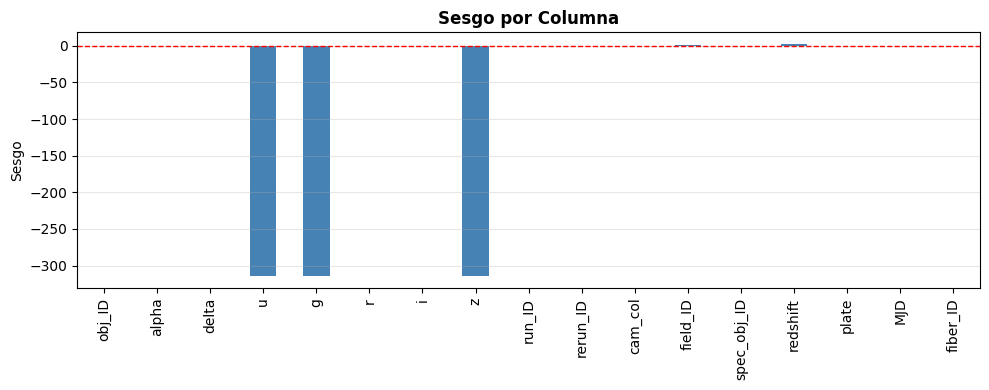

In [233]:

print("Analisis de Sesgo:")
skewness = df.select_dtypes(include=[np.number]).skew().round(3)
print(skewness)

skewness.plot(kind='bar', figsize=(10, 4), color='steelblue')
plt.title('Sesgo por Columna', fontsize=12, fontweight='bold')
plt.ylabel('Sesgo')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

- Como podemos observar tenemos valores altamente sesgados los cuales son los filtros fotonometricos como u,g,z y en menor medida nuestra variable objetivo, esto es algo malo, ya que los valores fotonometricos son los que deben ser los mejores predictores del redshit. Necesitamos investigar.

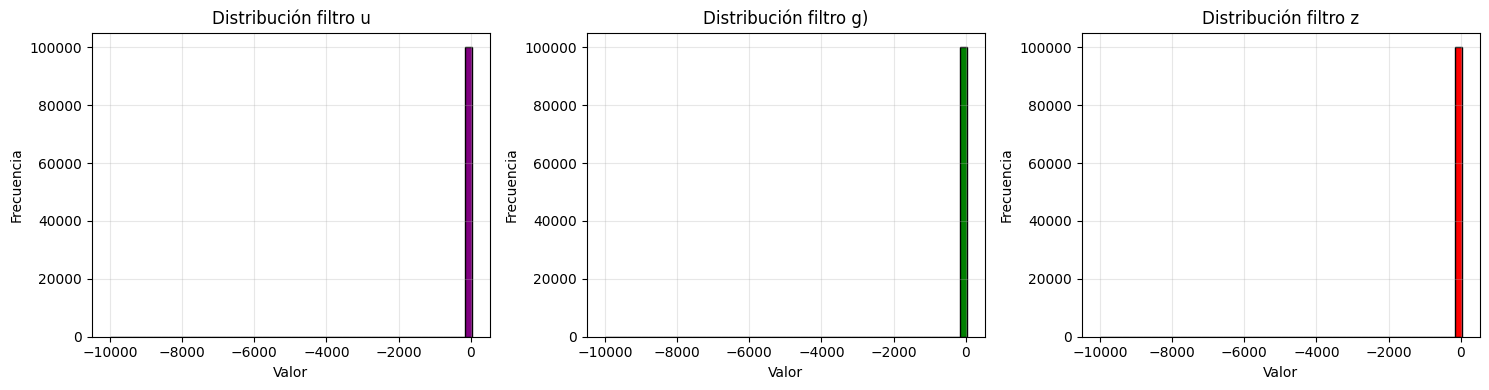

In [234]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['u'].hist(bins=50, ax=axes[0], color='purple', edgecolor='black')
axes[0].set_title('Distribución filtro u')
axes[0].set_xlabel('Valor')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(True, alpha=0.3)

df['g'].hist(bins=50, ax=axes[1], color='green', edgecolor='black')
axes[1].set_title('Distribución filtro g)')
axes[1].set_xlabel('Valor')
axes[1].set_ylabel('Frecuencia')
axes[1].grid(True, alpha=0.3)

df['z'].hist(bins=50, ax=axes[2], color='red', edgecolor='black')
axes[2].set_title('Distribución filtro z')
axes[2].set_xlabel('Valor')
axes[2].set_ylabel('Frecuencia')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- Efectivamente la distribucion esta sesgada, existe algun outlier, que nos esta distorsionando la variable, debe ser de un valor negativo, ya que nuestra visualizacion "se arastra" demasiado al negativo tal como nuestro analisis de sesgo.

In [235]:
print("Filtro u - Min:", df['u'].min(), "Max:", df['u'].max(), "Moda:", df['u'].mode()[0])
print("Filtro g - Min:", df['g'].min(), "Max:", df['g'].max(), "Moda:", df['g'].mode()[0])
print("Filtro z - Min:", df['z'].min(), "Max:", df['z'].max(), "Moda:", df['z'].mode()[0])

Filtro u - Min: -9999.0 Max: 32.78139 Moda: 24.63465
Filtro g - Min: -9999.0 Max: 31.60224 Moda: 25.11438
Filtro z - Min: -9999.0 Max: 29.38374 Moda: 22.8269


- Viendo, valoes como el minimo, maximo y la moda(que en este caso puede ser util), vemos que el minimo es un valor extremo.

In [236]:
print("Valores (-9999) en filtros fotométricos:")
print(f"Filtro u: {(df['u'] == -9999).sum()}")
print(f"Filtro g: {(df['g'] == -9999).sum()}")
print(f"Filtro z: {(df['z'] == -9999).sum()}")

Valores (-9999) en filtros fotométricos:
Filtro u: 1
Filtro g: 1
Filtro z: 1


- Podemos ver que este valor seguramente se trata de algun error, ya que solamente sucede una vez, puede que en la misma fila

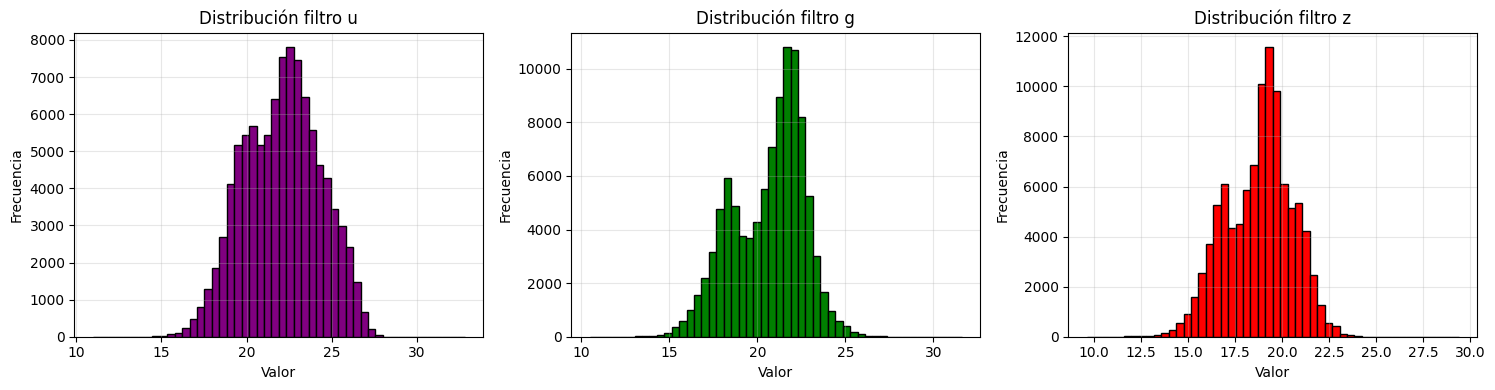

In [237]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df[df['u'] > -100]['u'].hist(bins=50, ax=axes[0], color='purple', edgecolor='black')
axes[0].set_title('Distribución filtro u')
axes[0].set_xlabel('Valor')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(True, alpha=0.3)

df[df['g'] > -100]['g'].hist(bins=50, ax=axes[1], color='green', edgecolor='black')
axes[1].set_title('Distribución filtro g')
axes[1].set_xlabel('Valor')
axes[1].set_ylabel('Frecuencia')
axes[1].grid(True, alpha=0.3)

df[df['z'] > -100]['z'].hist(bins=50, ax=axes[2], color='red', edgecolor='black')
axes[2].set_title('Distribución filtro z')
axes[2].set_xlabel('Valor')
axes[2].set_ylabel('Frecuencia')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- Ahora que filtramos el valor, se ven "normales", tendremos que eliminar filas con ese valor despues.

Analisis de Outliers:


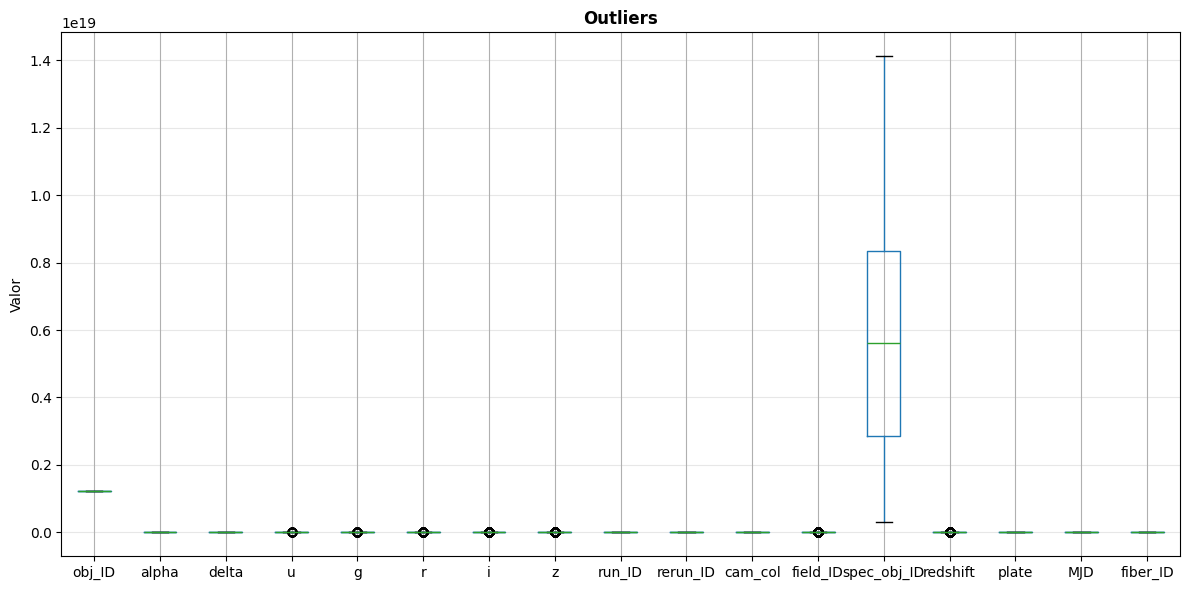

In [238]:
print("Analisis de Outliers:")

df.boxplot(figsize=(12, 6))
plt.title('Outliers', fontsize=12, fontweight='bold')
plt.ylabel('Valor')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


- Todos los valores estan "normalizados" alrededor de 0, lo cual tiene sentido para un dataset astronomico, unicamente destacan obj_ID y spec_obj_ID, los cual tenemos que eliminar ya que se tratan de etiquetas


Gráficos de distribución para cada columna


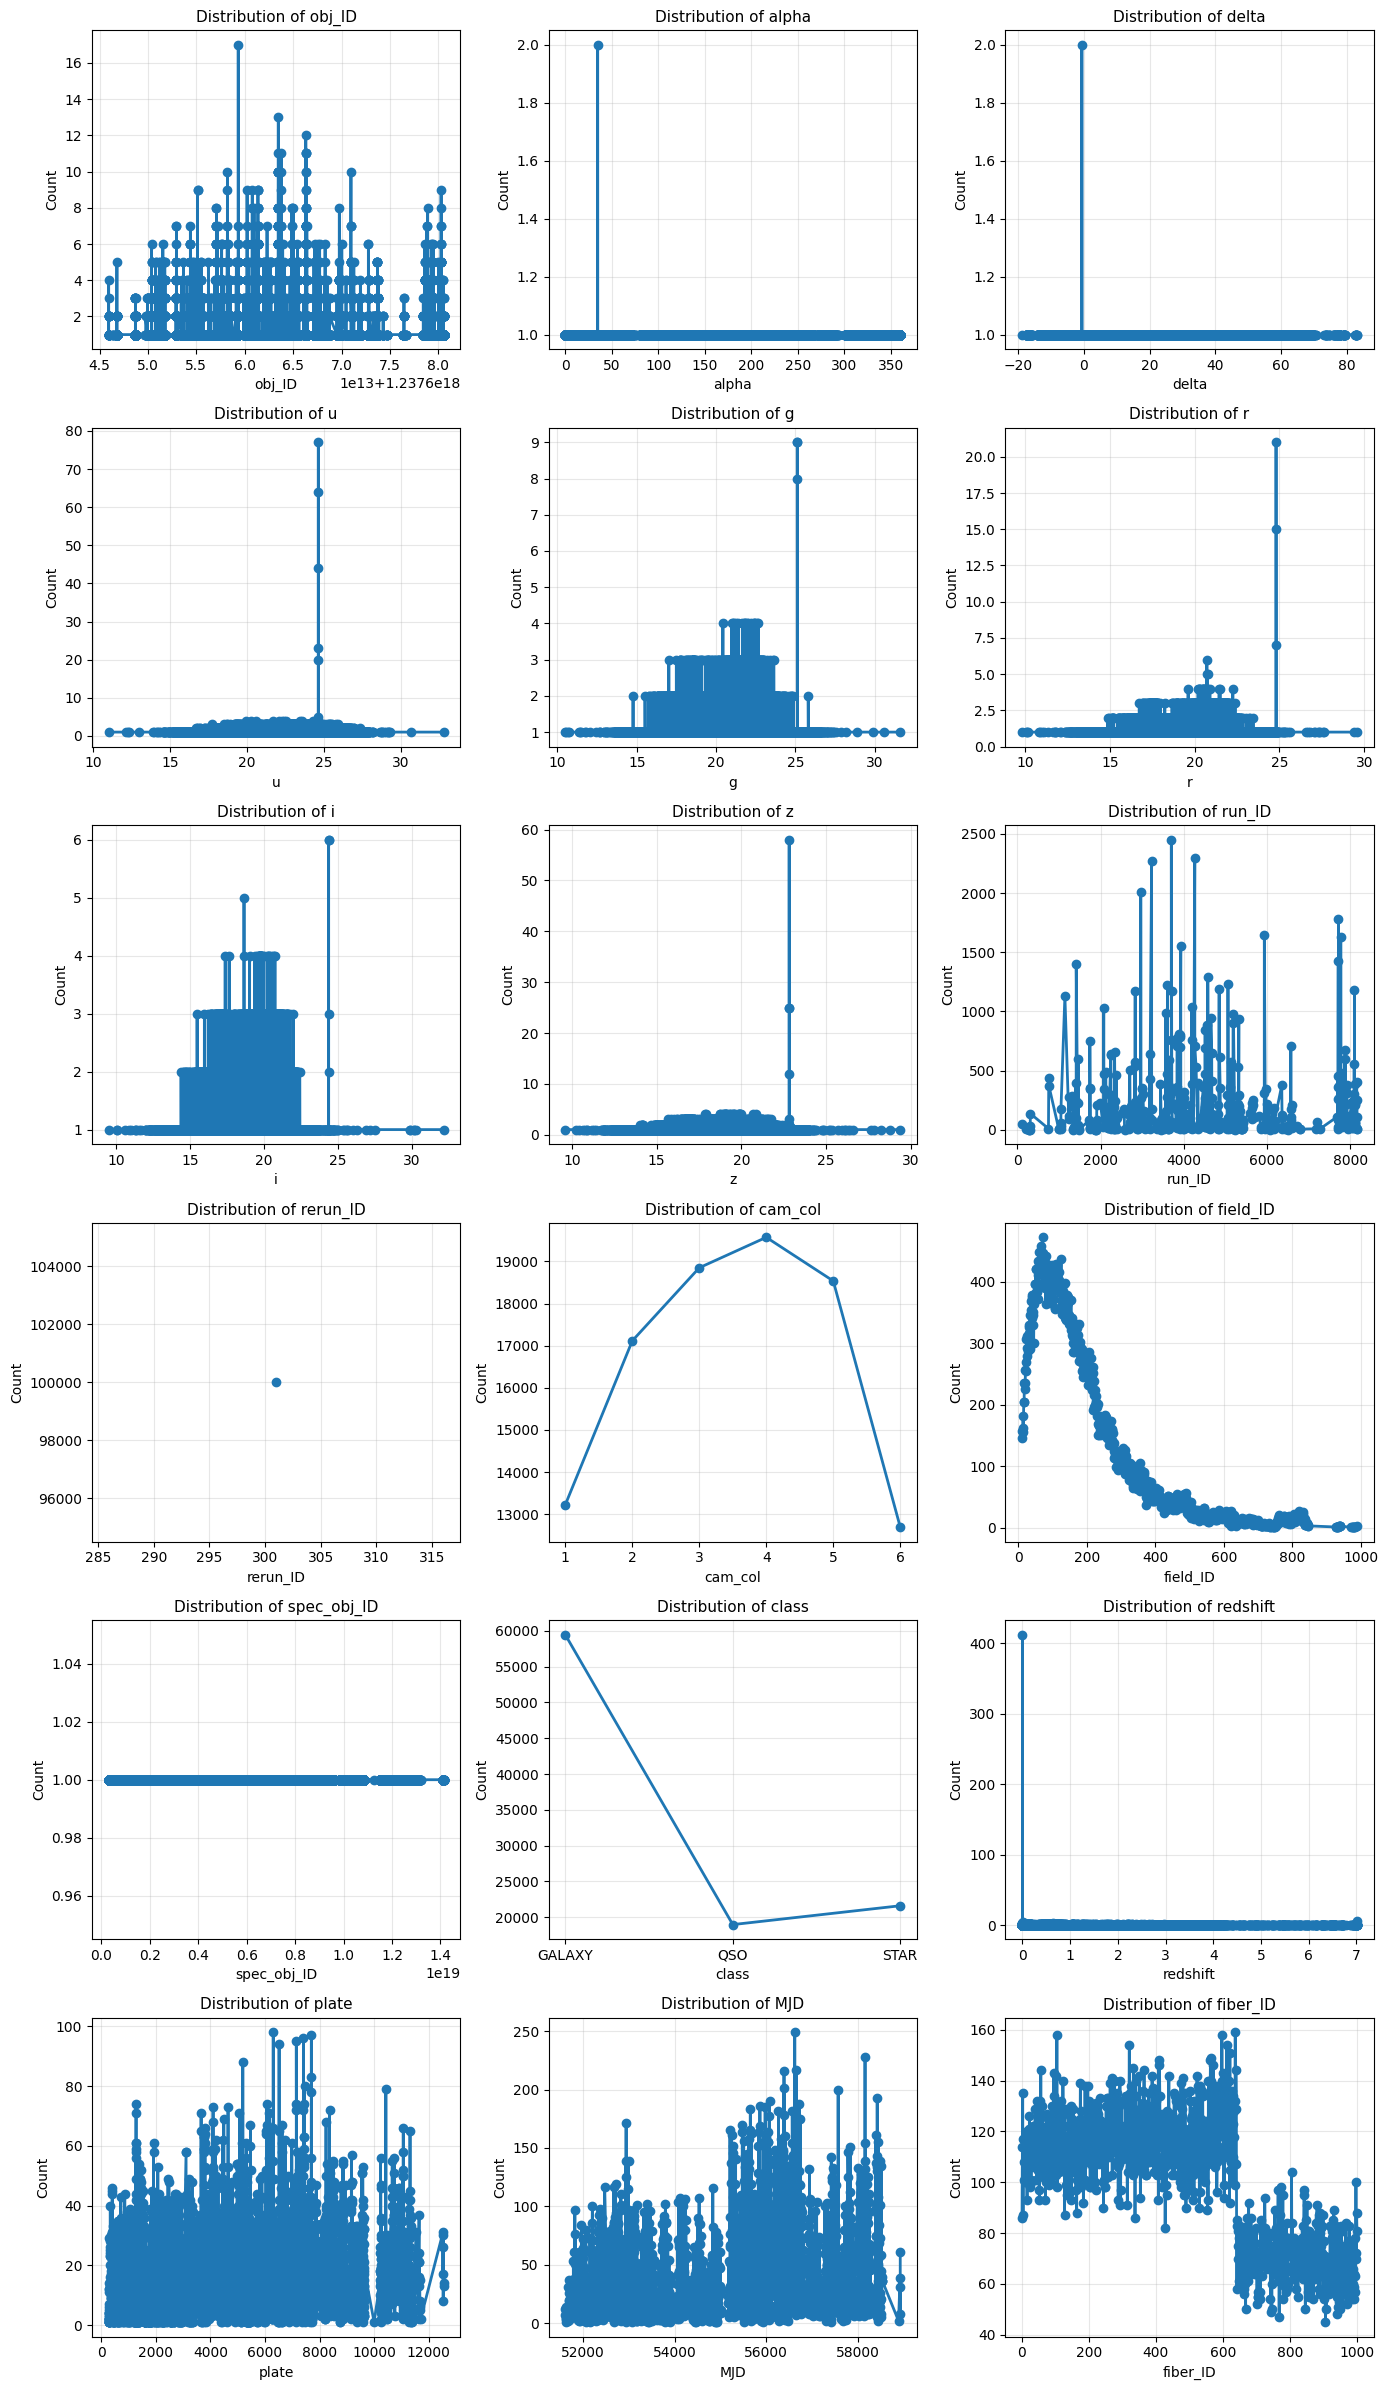

In [239]:
print("\nGráficos de distribución para cada columna")
n_cols = 3
n_rows = (len(df.columns) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for idx, column_name in enumerate(df.columns):
    if column_name in ['u', 'g', 'z']:
        data_filtered = df[df[column_name] != -9999][column_name]
        value_counts = data_filtered.value_counts().sort_index()
    else:
        value_counts = df[column_name].value_counts().sort_index()
    
    axes[idx].plot(value_counts.index, value_counts.values, marker='o', linestyle='-', linewidth=2)
    axes[idx].set_xlabel(column_name, fontsize=10)
    axes[idx].set_ylabel('Count', fontsize=10)
    axes[idx].set_title(f'Distribution of {column_name}', fontsize=11)
    axes[idx].grid(True, alpha=0.3)

for idx in range(len(df.columns), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

- Podemos ver que redshift, nuestra variable objetivo tiene un valor que se repite mucho alrededor de 0, es necesario analizar esto.
- Podemos Observar aqui que las siguientes variables las podemos descartar
    - *rerun_id*: No tiene ninguna varianza.
    - *spec_obj_id*: Se trata de un ID

In [240]:
print("Análisis de redshift:")
print(f"Redshift - Min: {df['redshift'].min()}")
print(f"Redshift - Max: {df['redshift'].max()}")
print(f"Moda: {df['redshift'].mode()[0]}")
print(f"Media: {df['redshift'].mean():.4f}")
print(f"Mediana: {df['redshift'].median():.4f}")
print(f"Valores únicos: {df['redshift'].nunique()}")

print(f"\nValores de redshift == 0: {(df['redshift'] == 0).sum()}")
print(f"Porcentaje de redshift == 0: {(df['redshift'] == 0).sum() / len(df) * 100:.2f}%")

print("\nDistribución de 'class' para redshift == 0:")
print(df[df['redshift'] == 0]['class'].value_counts())

Análisis de redshift:
Redshift - Min: -0.009970667
Redshift - Max: 7.011245
Moda: 0.0
Media: 0.5767
Mediana: 0.4242
Valores únicos: 99295

Valores de redshift == 0: 412
Porcentaje de redshift == 0: 0.41%

Distribución de 'class' para redshift == 0:
class
GALAXY    412
Name: count, dtype: int64


- Podemos ver que 0 se repite 412 veces, investigue en internet y descubri que 0 en redshift significan objetos cercanos, por lo que esas 412 galaxias son aquellas que son relativamente cercanas y estaticas

- Aquellas que son menor a 0 son "blueshift", aquellas galaxias o objetos que se estan acercando a la tierra, como en el caso de Andromeda

- Me entro curiosidad para ver cual es el redshift de las estrellas porque ninguna en 0 es una estrella, mi hipotesis es que todas las estrellas tienene un redshift debajo de 0, 

In [241]:
print("Análisis de Estrellas:")
stars = df[df['class'] == 'STAR']

stars_above_0 = stars[stars['redshift'] > 0]

print(f"Total de estrellas en el dataset: {len(stars)}")
print(f"Estrellas con redshift > 0: {len(stars_above_0)}")
print(f"Porcentaje de estrellas con redshift > 0: {(len(stars_above_0) / len(stars)) * 100:.2f}%")

print(f"\nEstrellas con redshift == 0: {len(stars[stars['redshift'] == 0])}")
print(f"Estrellas con redshift < 0: {len(stars[stars['redshift'] < 0])}")

print(f"\nEstadísticas de redshift para estrellas con redshift > 0:")
print(f"  - Mínimo: {stars_above_0['redshift'].min():.6f}")
print(f"  - Máximo: {stars_above_0['redshift'].max():.6f}")
print(f"  - Media: {stars_above_0['redshift'].mean():.6f}")
print(f"  - Mediana: {stars_above_0['redshift'].median():.6f}")

Análisis de Estrellas:
Total de estrellas en el dataset: 21594
Estrellas con redshift > 0: 7912
Porcentaje de estrellas con redshift > 0: 36.64%

Estrellas con redshift == 0: 0
Estrellas con redshift < 0: 13682

Estadísticas de redshift para estrellas con redshift > 0:
  - Mínimo: 0.000000
  - Máximo: 0.004153
  - Media: 0.000250
  - Mediana: 0.000134


- Podemos observar que no, que mas de un cuarto estan mas alla de 0, pero el valor maximo es de 0.004153, que significa una estrella que se esta alejando velozmente de nosotros, pero en la escala cosmologica es extremadamente lenta, es por esto que a las estrellas no les afecta la expansion del universo, segun la mediana (0.000134, la mayoria de estrellas se mueven lentamente.

- Algo interesante es que que las estrellas en el dataset son solo aquellas en la via lactea, sin contar las de otras galaxias.

### 1.3 Limpieza de Datos

##### 1.3.1 Decisiones de Limpieza

Basado en el análisis exploratorio, procederemos a limpiar el dataset:

1. **Valores extremos en filtros (-9999)**: En los filtros u, g, z (son mediciones invalidad)
2. **Columnas ID sin valor predictivo**: obj_ID, spec_obj_ID, run_ID, field_ID, plate, fiber_ID, MJD
3. **Columnas técnicas sin varianza**: rerun_ID (solo tiene 1 valor único), cam_col (información técnica de la cámara)
4. **Hacer "encoding" variable categórica**: Transformar 'class' a valores numéricos

In [242]:
print("Dataset original:")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
print(f"Columnas: {list(df.columns)}")

Dataset original:
Filas: 100000, Columnas: 18
Columnas: ['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift', 'plate', 'MJD', 'fiber_ID']


In [243]:

df_clean = df[(df['u'] != -9999) & (df['g'] != -9999) & (df['z'] != -9999)]

print(f"Filas eliminadas: {len(df) - len(df_clean)}")
print(f"Filas restantes: {len(df_clean)}")

Filas eliminadas: 1
Filas restantes: 99999


In [244]:
columns_to_drop = ['obj_ID', 'spec_obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'plate', 'MJD', 'fiber_ID']

df_clean = df_clean.drop(columns=columns_to_drop)

print(f"Columnas eliminadas: {len(columns_to_drop)}")
print(f"Columnas restantes: {df_clean.shape[1]}")
print(f"Columnas: {list(df_clean.columns)}")

Columnas eliminadas: 9
Columnas restantes: 9
Columnas: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'class', 'redshift']


In [245]:
print("Valores únicos antes de codificar:")
print(df_clean['class'].value_counts())

# One hot encoding
class_dummies = pd.get_dummies(df_clean['class'], prefix='class')
df_clean = pd.concat([df_clean, class_dummies], axis=1)

print("\nColumnas añadidas:", list(class_dummies.columns))
print("\nValores después de One-Hot Encoding (muestra):")
print(df_clean[class_dummies.columns].head())

Valores únicos antes de codificar:
class
GALAXY    59445
STAR      21593
QSO       18961
Name: count, dtype: int64

Columnas añadidas: ['class_GALAXY', 'class_QSO', 'class_STAR']

Valores después de One-Hot Encoding (muestra):
   class_GALAXY  class_QSO  class_STAR
0          True      False       False
1          True      False       False
2          True      False       False
3          True      False       False
4          True      False       False


In [246]:
print("Datos después de la limpieza:")

print(f"\nDataset original:")
print(f"  - Filas: {df.shape[0]}")
print(f"  - Columnas: {df.shape[1]}")

print(f"\nDataset limpio :")
print(f"  - Filas: {df_clean.shape[0]}")
print(f"  - Columnas: {df_clean.shape[1]}")

print(f"\nColumnas finales:")
print(df_clean.dtypes)

Datos después de la limpieza:

Dataset original:
  - Filas: 100000
  - Columnas: 18

Dataset limpio :
  - Filas: 99999
  - Columnas: 12

Columnas finales:
alpha           float64
delta           float64
u               float64
g               float64
r               float64
i               float64
z               float64
class            object
redshift        float64
class_GALAXY       bool
class_QSO          bool
class_STAR         bool
dtype: object


##### 1.3.2 Explicación de Decisiones Tomadas

1. **celdas con valor -99999:**
   - Representa mediciones inválidas
   - Solo 1 fila de 100,000
   - Distorciona la varianza

2. **columnas de ID:**
   - obj_ID, spec_obj_ID, run_ID, field_ID, plate, fiber_ID, MJD son solo identificadores o metadatos técnicos
   - Incluirlas causaría overfitting

3. **rerun_ID y cam_col:**
   - rerun_ID: Solo tiene 1 valor único 
   - cam_col: Información técnica de la cámara sin relación física con redshift

4. **encoding para 'class':**
   - Los modelos de regresión requieren entrada numérica
   - GALAXY=0, STAR=1, QSO=2 
   - El tipo de objeto astronómico puede tener relación con su redshift

5. **¿Por qué mantener redshift = 0 y redshift < 0?**
   - Son valores físicamente válidos (objetos cercanos o en blueshift)
   - Representan mediciones reales
   - Proporcionan información valiosa sobre el rango completo de distancias

### 1.4 Análisis de Relaciones entre Variables

#### 1.4.1 Matriz de Correlación

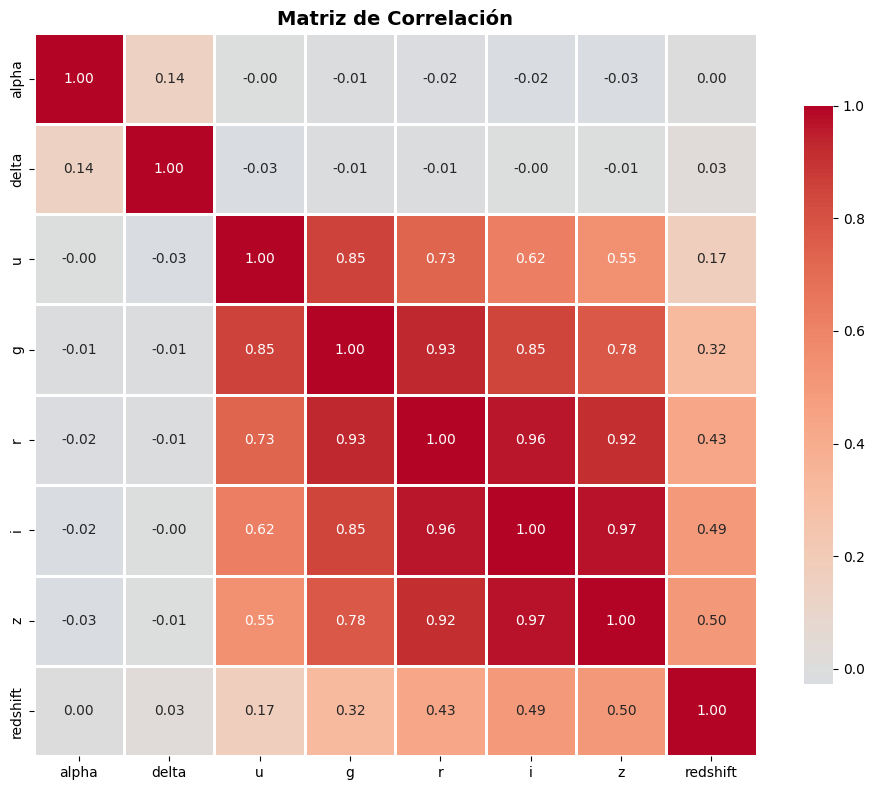

Correlación con redshift:
redshift    1.000000
z           0.501060
i           0.492381
r           0.433237
g           0.318910
u           0.166816
delta       0.031629
alpha       0.001671
Name: redshift, dtype: float64


In [247]:

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
cols_for_corr = [c for c in numeric_cols if not c.startswith('class_') and c not in ['redshift', 'redshift_log1p']]

if 'redshift' not in cols_for_corr:
    cols_for_corr.append('redshift')

correlation = df_clean[cols_for_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlación con redshift:")

redshift_corr = correlation['redshift'].copy()
print(redshift_corr.sort_values(ascending=False))

- Podemos observar que la clase (estrella, quazar o galaxia) es la variable con mas relacion al redshift, de la misma manera los filtros son buenos predictores como esperados, mientras que los angulos "delta" y "alpha" lo son menos.

#### 1.4.2 Relación entre Filtros Fotométricos y Redshift

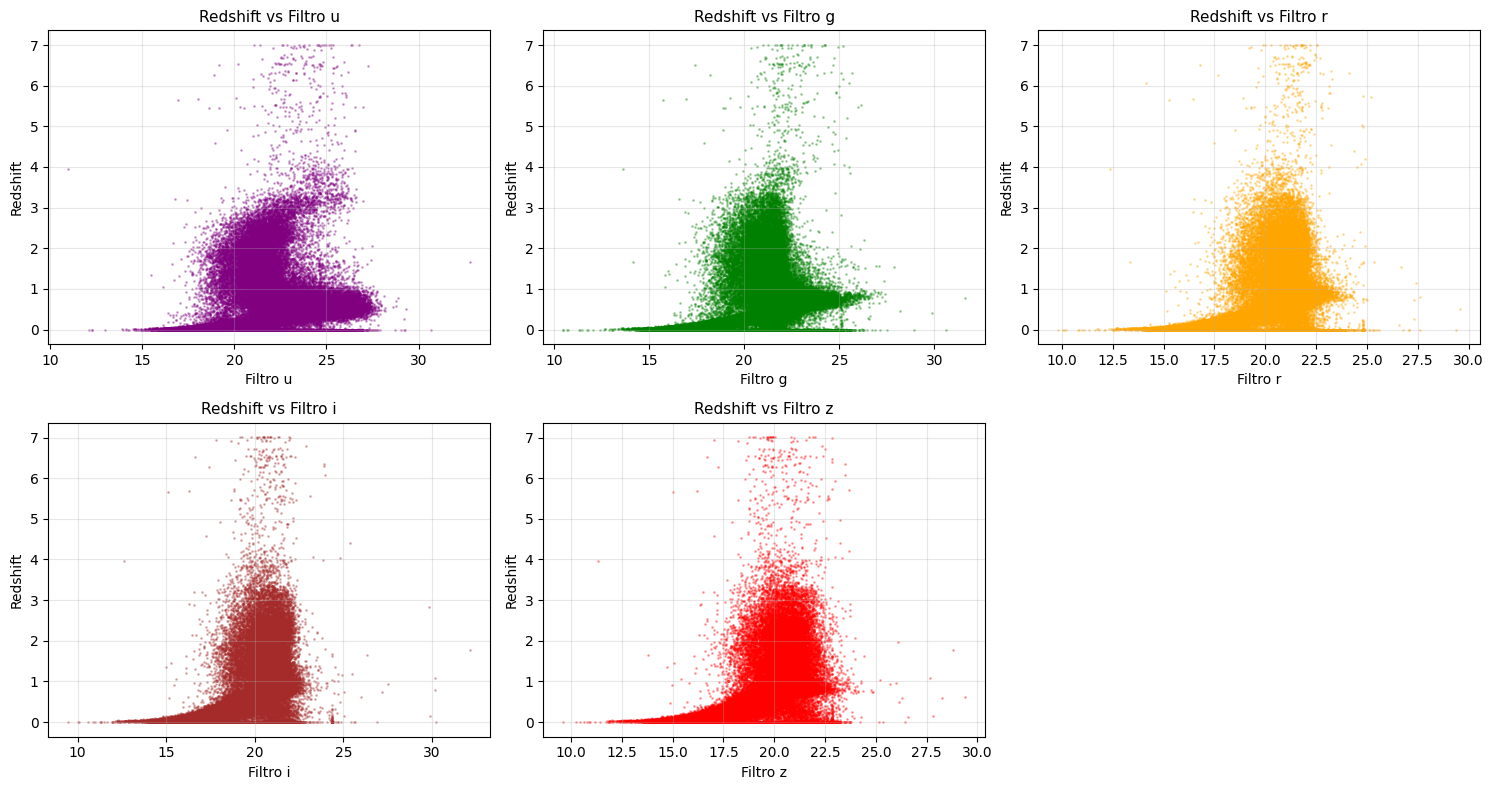

In [248]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

filters = ['u', 'g', 'r', 'i', 'z']
colors = ['purple', 'green', 'orange', 'brown', 'red']

for idx, (filter_name, color) in enumerate(zip(filters, colors)):
    axes[idx].scatter(df_clean[filter_name], df_clean['redshift'], 
                     alpha=0.3, s=1, c=color)
    axes[idx].set_xlabel(f'Filtro {filter_name}', fontsize=10)
    axes[idx].set_ylabel('Redshift', fontsize=10)
    axes[idx].set_title(f'Redshift vs Filtro {filter_name}', fontsize=11)
    axes[idx].grid(True, alpha=0.3)

axes[5].set_visible(False)

plt.tight_layout()
plt.show()

- Podemos observar una clara relacion entre redshift y los filtros, ya que se forma una "linea" vertical, tiene sentido porque cada filtro captura una diferente longitud de onda de luz, lo cual está directamente relacionado con el redshift.

#### 1.4.3 Distribución de Redshift por Tipo de Objeto Astronómico

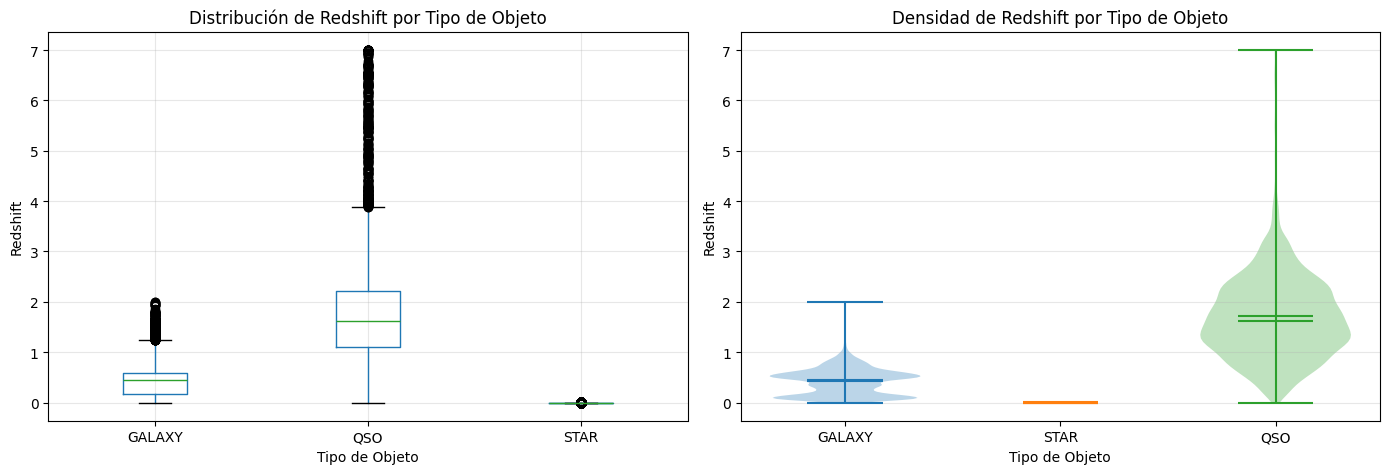

In [249]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_clean['class_name'] = df_clean['class']

df_clean.boxplot(column='redshift', by='class_name', ax=axes[0])
axes[0].set_title('Distribución de Redshift por Tipo de Objeto')
axes[0].set_xlabel('Tipo de Objeto')
axes[0].set_ylabel('Redshift')
axes[0].get_figure().suptitle('') 
axes[0].grid(True, alpha=0.3)

class_order = ['GALAXY', 'STAR', 'QSO']
for idx, class_name in enumerate(class_order):
    data = df_clean[df_clean['class_name'] == class_name]['redshift']
    parts = axes[1].violinplot([data], positions=[idx], widths=0.7, showmeans=True, showmedians=True)
    
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(class_order)
axes[1].set_xlabel('Tipo de Objeto')
axes[1].set_ylabel('Redshift')
axes[1].set_title('Densidad de Redshift por Tipo de Objeto')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

df_clean = df_clean.drop('class_name', axis=1)

**Observaciones**

- **GALAXY (Galaxias)**: Tienen redshift variados, desde cercanas hasta lejanas
- **STAR (Estrellas)**: Tienden a tener un redshift bajo debido a que se encuentran en nuestra propia galaxia
- **QSO (Quásares)**: Tienden a tener redshift más alto, ya que son objetos muy distantes y antiguos

En conclusión, la clase es una de las mejores predictoras del redshift.

#### 1.4.4 Distribución de Variables Predictoras

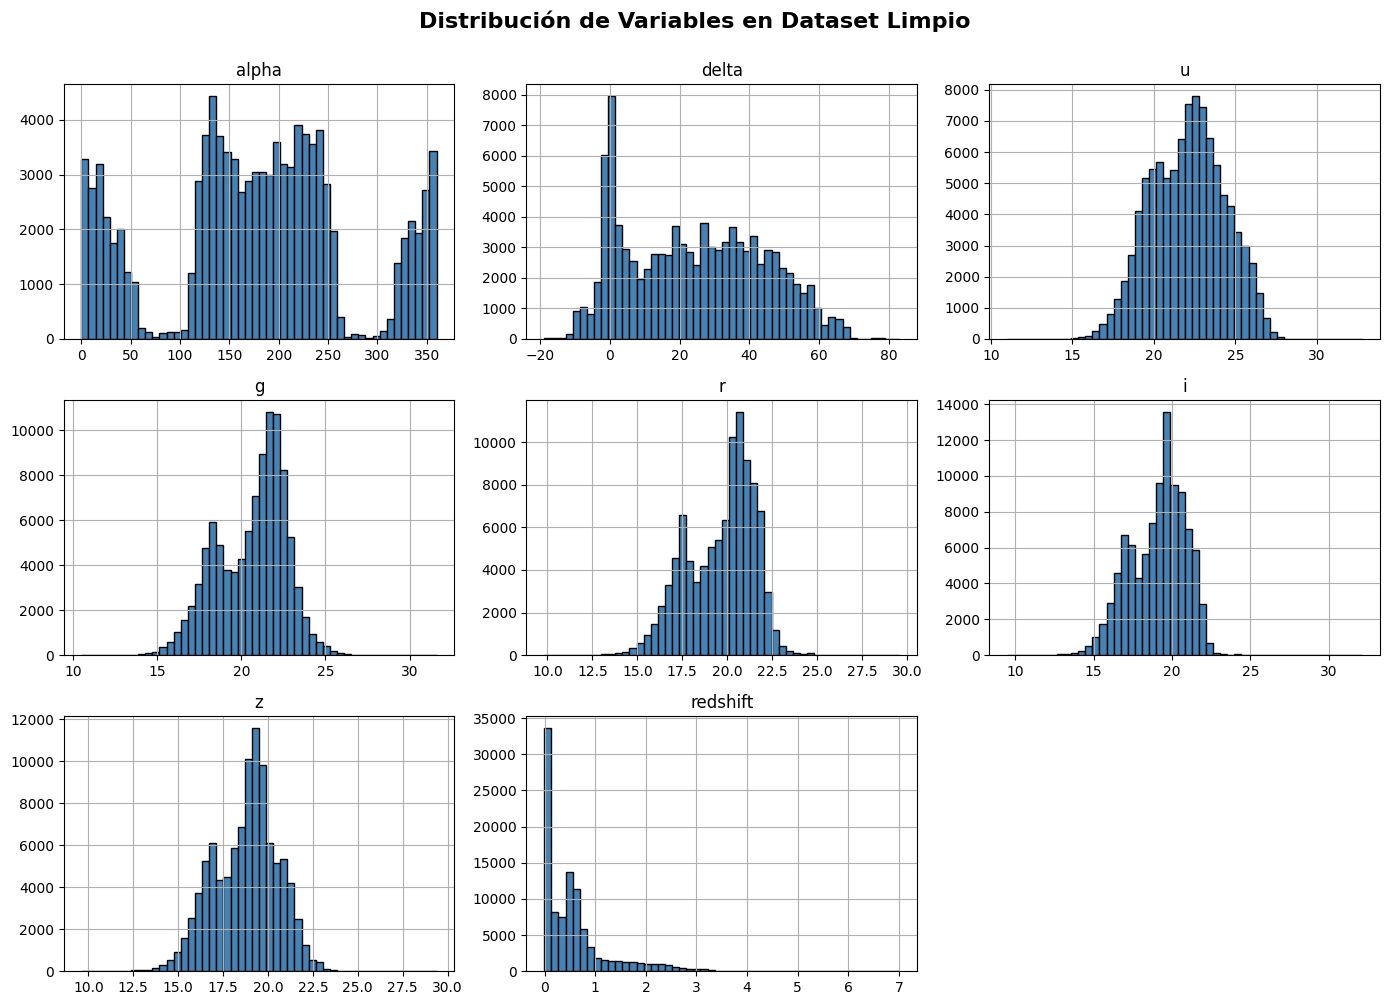

In [250]:

df_clean.hist(bins=50, figsize=(14, 10), edgecolor='black', color='steelblue')
plt.suptitle('Distribución de Variables en Dataset Limpio', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

**Observaciones sobre las Distribuciones**

- **Filtros fotométricos (u, g, r, i, z)**: Después de eliminar el valor anormal, las distribuciones son normales y apropiadas para la regresion.
- **Alpha y delta**: Representan coordenadas celestes, delta tiene una distribucion normal, mientras que alpha una multimodal, la verdad esto no es muy importante, porque solo significa que la camara capturo el cielo en "batches" y zonas especificas.
- **Redshift**: Tiene un alto sesgo positivo, lo cual es bueno, ya que la mayoria de cuerpos son cercanos no lejanos.
- **Class**: Variable categórica codificada (0=GALAXY, 1=STAR, 2=QSO)

### 1.5 Division de Datos

In [251]:
X = df_clean.drop('redshift', axis=1)
y = df_clean['redshift']

print("Dimensiones antes de la división:")
print(f"X: {X.shape}")
print(f"y: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nDimensiones después de la división:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

print(f"\nPorcentaje de datos de entrenamiento: {len(X_train)/len(X)*100:.2f}%")
print(f"Porcentaje de datos de prueba: {len(X_test)/len(X)*100:.2f}%")

Dimensiones antes de la división:
X: (99999, 11)
y: (99999,)

Dimensiones después de la división:
X_train: (79999, 11)
X_test: (20000, 11)
y_train: (79999,)
y_test: (20000,)

Porcentaje de datos de entrenamiento: 80.00%
Porcentaje de datos de prueba: 20.00%


**Explicación de la División:**
- Utilizamos una división 80-20, que es estándar para datasets de este tamaño
- El conjunto de entrenamiento se usará para entrenar los modelos
- El conjunto de prueba se usará solo para evaluar el rendimiento final

### 1.6 Escalado de Datos

Estadísticas antes del escalado (datos de entrenamiento) — numéricas:
       alpha  delta      u      g      r      i      z
mean  177.48  24.15  22.08  20.63  19.65  19.08  18.77
std    96.44  19.66   2.25   2.04   1.86   1.76   1.77

Estadísticas después del escalado (datos de entrenamiento) — numéricas:
      alpha  delta    u    g    r    i    z
mean   -0.0    0.0  0.0 -0.0  0.0  0.0 -0.0
std     1.0    1.0  1.0  1.0  1.0  1.0  1.0


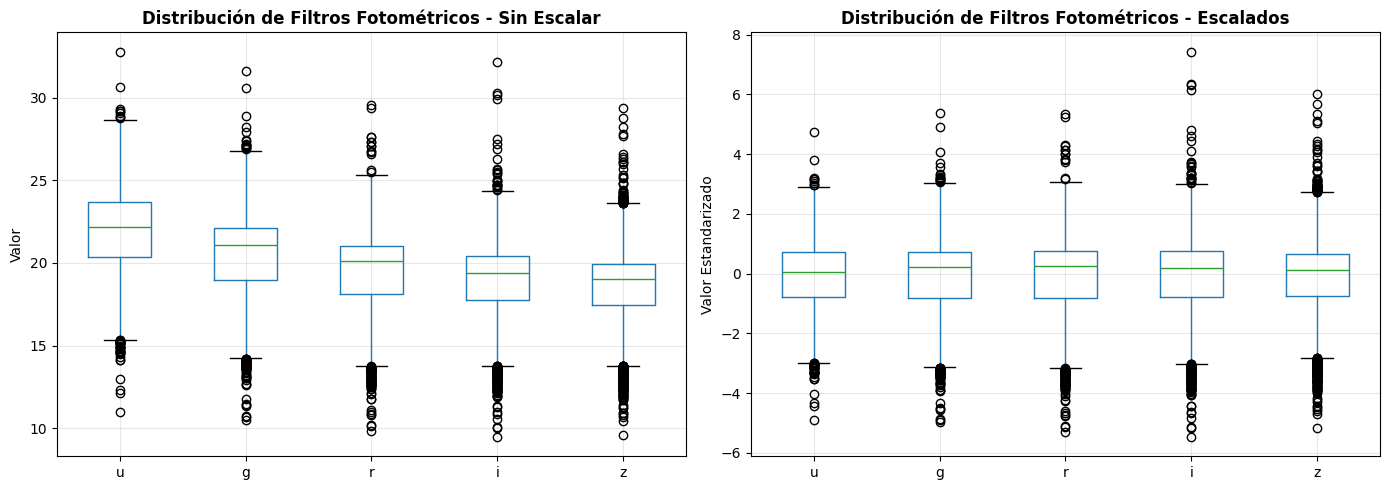

In [252]:
scaler = StandardScaler()

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

numeric_features = [c for c in numeric_features if not c.startswith('class')]


X_train_num = X_train[numeric_features].copy()
X_test_num = X_test[numeric_features].copy()

X_train_num_scaled = pd.DataFrame(scaler.fit_transform(X_train_num), columns=numeric_features, index=X_train.index)
X_test_num_scaled = pd.DataFrame(scaler.transform(X_test_num), columns=numeric_features, index=X_test.index)

non_scaled_cols = [c for c in X_train.columns if c not in numeric_features]

X_train_scaled = pd.concat([X_train_num_scaled, X_train[non_scaled_cols]], axis=1)[X_train.columns]
X_test_scaled = pd.concat([X_test_num_scaled, X_test[non_scaled_cols]], axis=1)[X_test.columns]

print("Estadísticas antes del escalado (datos de entrenamiento) — numéricas:")
print(X_train[numeric_features].describe().loc[['mean', 'std']].round(2))

print("\nEstadísticas después del escalado (datos de entrenamiento) — numéricas:")
print(X_train_num_scaled.describe().loc[['mean', 'std']].round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if set(['u','g','r','i','z']).issubset(set(numeric_features)):
    X_train[['u', 'g', 'r', 'i', 'z']].boxplot(ax=axes[0])
    axes[0].set_title('Distribución de Filtros Fotométricos - Sin Escalar', fontweight='bold')
    axes[0].set_ylabel('Valor')
    axes[0].grid(True, alpha=0.3)
    
    X_train_num_scaled[['u', 'g', 'r', 'i', 'z']].boxplot(ax=axes[1])
    axes[1].set_title('Distribución de Filtros Fotométricos - Escalados', fontweight='bold')
    axes[1].set_ylabel('Valor Estandarizado')
    axes[1].grid(True, alpha=0.3)
else:
    axes[0].text(0.5, 0.5, 'No hay las 5 columnas de filtros en numeric_features', ha='center')
    axes[1].axis('off')

plt.tight_layout()
plt.show()

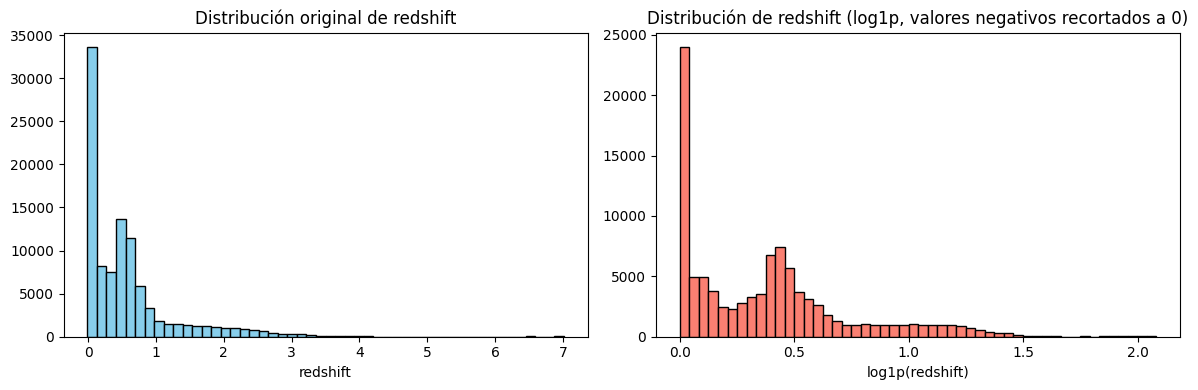

Añadida columna redshift_log1p a df_clean (se recortaron valores negativos antes de aplicar log1p).


In [253]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

axes[0].hist(df_clean['redshift'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Distribución original de redshift')
axes[0].set_xlabel('redshift')

y_log = np.log1p(df_clean['redshift'].clip(lower=0))
axes[1].hist(y_log, bins=50, color='salmon', edgecolor='black')
axes[1].set_title('Distribución de redshift (log1p, valores negativos recortados a 0)')
axes[1].set_xlabel('log1p(redshift)')
plt.tight_layout()
plt.show()

df_clean['redshift_log1p'] = np.log1p(df_clean['redshift'].clip(lower=0))
print('Añadida columna redshift_log1p a df_clean (se recortaron valores negativos antes de aplicar log1p).')

**¿Por qué es necesario el escalado?**

1. **Diferentes escalas**: Las variables tienen rangos muy diferentes 
2. **Mejora el rendimiento**: Muchos algoritmos son sensibles a la escala de las variables

#### Yo eligiria Random Forest, pero...

No es un modelo perfecto, es el "default" porque los filtros tienen alta multicolinearidad y tenemos una variable categorica, que en modelos como Ridge y Lasso podrian confundir al modelo por no tener una relacion lineal.

El problema es que no es ideal, porque tiene muy baja interpretabilidad, y para la ciencia, yo creo que es muy importante la interpretacion.

Lo que se me ocurre es hacer un modelo de regresion lineal simple por filtro en relacion al redshift, y despues de comprender su impacto aplicamos random forest con todas las variables.

### Entrega 2 (Modelado):


### 2.1 Preparación de Datos para Modelado

Antes de entrenar los modelos, necesitamos preparar correctamente nuestros datos:
- Separar las variables predictoras (X) de la variable objetivo (y)
- Verificar que las variables categóricas estén correctamente codificadas
- Asegurar que los datos escalados estén listos para los modelos

In [254]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score, GridSearchCV
import time

In [255]:
print("Forma de los conjuntos de datos:")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

print("\nColumnas en X_train_scaled:")
print(list(X_train_scaled.columns))

class_cols = [col for col in X_train_scaled.columns if col.startswith('class_')]
print(f"\nColumnas de clase (one-hot): {class_cols}")

if 'class' in X_train_scaled.columns:
    X_train_final = X_train_scaled.drop('class', axis=1)
    X_test_final = X_test_scaled.drop('class', axis=1)
else:
    X_train_final = X_train_scaled
    X_test_final = X_test_scaled

if 'redshift_log1p' in X_train_final.columns:
    X_train_final = X_train_final.drop('redshift_log1p', axis=1)
    X_test_final = X_test_final.drop('redshift_log1p', axis=1)

print(f"\nForma final de los datos:")
print(f"X_train_final: {X_train_final.shape}")
print(f"X_test_final: {X_test_final.shape}")

Forma de los conjuntos de datos:
X_train_scaled: (79999, 11)
X_test_scaled: (20000, 11)
y_train: (79999,)
y_test: (20000,)

Columnas en X_train_scaled:
['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'class', 'class_GALAXY', 'class_QSO', 'class_STAR']

Columnas de clase (one-hot): ['class_GALAXY', 'class_QSO', 'class_STAR']

Forma final de los datos:
X_train_final: (79999, 10)
X_test_final: (20000, 10)


### 2.2 Selección de Modelos a Comparar

Vamos a comparar 5 modelos de regresión diferentes:

1. **Regresión Lineal Simple**
2. **Ridge Regression**
3. **Lasso Regression**
4. **Random Forest**
5. **Gradient Boosting**

#### Justificación de Métricas de Performance

Para este proyecto usaremos tres métricas principales:

- **R² (Coeficiente de Determinación)**: Mide qué tan bien el modelo explica la varianza de los datos (0-1, mayor es mejor)
- **RMSE (Root Mean Squared Error)**: Penaliza más los errores grandes, útil para detectar predicciones muy desviadas
- **MAE (Mean Absolute Error)**: Error promedio absoluto, más robusto a outliers que RMSE

**Métrica principal**: Usaremos **R²** como métrica principal

### 2.3 Entrenamiento de Modelos Base

Primero entrenaremos todos los modelos con sus hiperparámetros por defecto para establecer una línea base.

In [256]:
results = {
    'Model': [],
    'Train_Time': [],
    'Train_R2': [],
    'Test_R2': [],
    'Train_RMSE': [],
    'Test_RMSE': [],
    'Train_MAE': [],
    'Test_MAE': [],
    'N_Parameters': []
}

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """
    Entrena y evalúa un modelo de regresión
    """
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    if hasattr(model, 'coef_'):
        n_params = len(model.coef_) + 1  
    elif hasattr(model, 'n_estimators'):
        n_params = model.n_estimators 
    else:
        n_params = 'N/A'
    

    results['Model'].append(model_name)
    results['Train_Time'].append(train_time)
    results['Train_R2'].append(train_r2)
    results['Test_R2'].append(test_r2)
    results['Train_RMSE'].append(train_rmse)
    results['Test_RMSE'].append(test_rmse)
    results['Train_MAE'].append(train_mae)
    results['Test_MAE'].append(test_mae)
    results['N_Parameters'].append(n_params)
    
  
    print(f"\n{'_'*60}")
    print(f"Modelo: {model_name}")
    print(f"{'_'*60}")
    print(f"Tiempo de entrenamiento: {train_time:.4f} segundos")
    print(f"Número de parámetros: {n_params}")
    print(f"\nMétricas de Entrenamiento:")
    print(f"  R²: {train_r2:.6f}")
    print(f"  RMSE: {train_rmse:.6f}")
    print(f"  MAE: {train_mae:.6f}")
    print(f"\nMétricas de Prueba:")
    print(f"  R²: {test_r2:.6f}")
    print(f"  RMSE: {test_rmse:.6f}")
    print(f"  MAE: {test_mae:.6f}")
    print(f"{'_'*60}")
    
    return model

In [257]:
# 1. Regresión Lineal Simple
print("Entrenando Regresión Lineal Simple...")
lr_model = LinearRegression()
lr_model = evaluate_model(lr_model, X_train_final, y_train, X_test_final, y_test, 
                          "Linear Regression")

Entrenando Regresión Lineal Simple...

____________________________________________________________
Modelo: Linear Regression
____________________________________________________________
Tiempo de entrenamiento: 0.0092 segundos
Número de parámetros: 11

Métricas de Entrenamiento:
  R²: 0.677662
  RMSE: 0.414771
  MAE: 0.225329

Métricas de Prueba:
  R²: 0.668838
  RMSE: 0.420843
  MAE: 0.227328
____________________________________________________________


In [258]:
# 2. Ridge Regression
print("Entrenando Ridge Regression...")
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model = evaluate_model(ridge_model, X_train_final, y_train, X_test_final, y_test, 
                             "Ridge Regression")

Entrenando Ridge Regression...

____________________________________________________________
Modelo: Ridge Regression
____________________________________________________________
Tiempo de entrenamiento: 0.0083 segundos
Número de parámetros: 11

Métricas de Entrenamiento:
  R²: 0.677662
  RMSE: 0.414771
  MAE: 0.225327

Métricas de Prueba:
  R²: 0.668839
  RMSE: 0.420842
  MAE: 0.227325
____________________________________________________________


In [259]:
# 3. Lasso Regression
print("Entrenando Lasso Regression...")
lasso_model = Lasso(alpha=0.001, random_state=42, max_iter=10000)
lasso_model = evaluate_model(lasso_model, X_train_final, y_train, X_test_final, y_test, 
                             "Lasso Regression")

Entrenando Lasso Regression...

____________________________________________________________
Modelo: Lasso Regression
____________________________________________________________
Tiempo de entrenamiento: 0.1733 segundos
Número de parámetros: 11

Métricas de Entrenamiento:
  R²: 0.677635
  RMSE: 0.414788
  MAE: 0.224983

Métricas de Prueba:
  R²: 0.668868
  RMSE: 0.420824
  MAE: 0.226983
____________________________________________________________


In [260]:
# 4. Random Forest
print("Entrenando Random Forest...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model = evaluate_model(rf_model, X_train_final, y_train, X_test_final, y_test, 
                          "Random Forest")

Entrenando Random Forest...



____________________________________________________________
Modelo: Random Forest
____________________________________________________________
Tiempo de entrenamiento: 5.6790 segundos
Número de parámetros: 100

Métricas de Entrenamiento:
  R²: 0.968188
  RMSE: 0.130301
  MAE: 0.046728

Métricas de Prueba:
  R²: 0.767146
  RMSE: 0.352892
  MAE: 0.127286
____________________________________________________________


In [261]:
# 5. Gradient Boosting
print("Entrenando Gradient Boosting...")
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=5)
gb_model = evaluate_model(gb_model, X_train_final, y_train, X_test_final, y_test, 
                          "Gradient Boosting")

Entrenando Gradient Boosting...

____________________________________________________________
Modelo: Gradient Boosting
____________________________________________________________
Tiempo de entrenamiento: 27.8438 segundos
Número de parámetros: 100

Métricas de Entrenamiento:
  R²: 0.800824
  RMSE: 0.326040
  MAE: 0.139776

Métricas de Prueba:
  R²: 0.750073
  RMSE: 0.365600
  MAE: 0.150628
____________________________________________________________


### 2.4 Comparación de Resultados de Modelos Base

In [262]:
results_df = pd.DataFrame(results)
print("\n" + "_"*120)
print("Comparativa de Modelos de Regresión (Base):")
print("_"*120)
print(results_df.to_string(index=False))
print("_"*120)


________________________________________________________________________________________________________________________
Comparativa de Modelos de Regresión (Base):
________________________________________________________________________________________________________________________
            Model  Train_Time  Train_R2  Test_R2  Train_RMSE  Test_RMSE  Train_MAE  Test_MAE  N_Parameters
Linear Regression    0.009152  0.677662 0.668838    0.414771   0.420843   0.225329  0.227328            11
 Ridge Regression    0.008281  0.677662 0.668839    0.414771   0.420842   0.225327  0.227325            11
 Lasso Regression    0.173323  0.677635 0.668868    0.414788   0.420824   0.224983  0.226983            11
    Random Forest    5.678981  0.968188 0.767146    0.130301   0.352892   0.046728  0.127286           100
Gradient Boosting   27.843832  0.800824 0.750073    0.326040   0.365600   0.139776  0.150628           100
_______________________________________________________________________

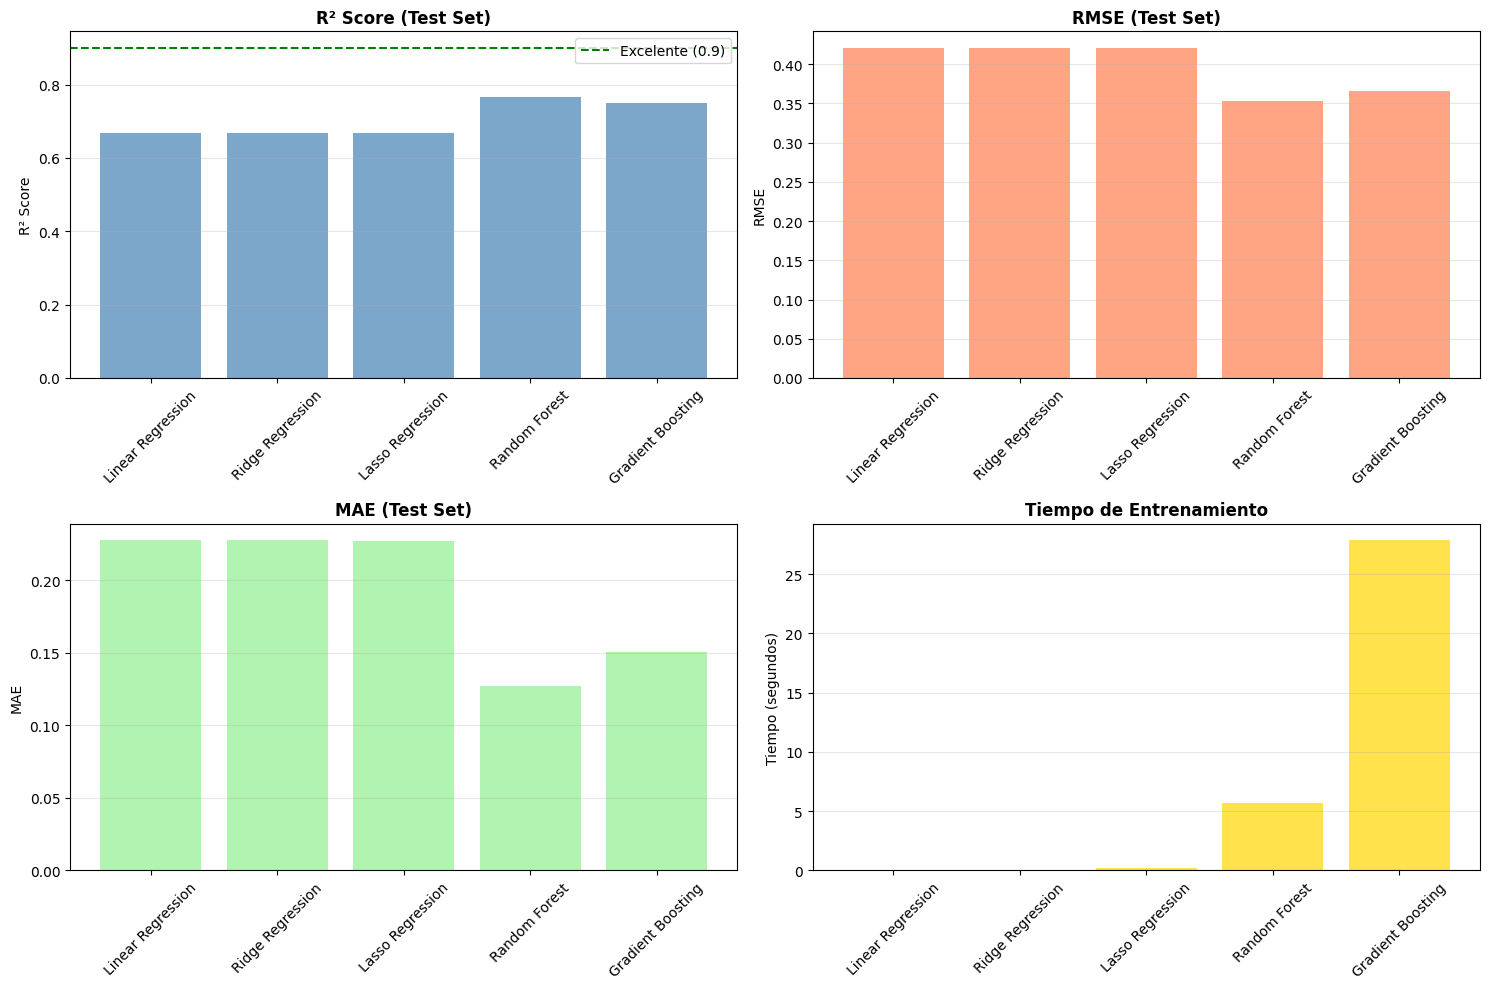

In [263]:
# Comparativa visual de los modelos
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# R² 
axes[0, 0].bar(results_df['Model'], results_df['Test_R2'], color='steelblue', alpha=0.7)
axes[0, 0].set_title('R² Score (Test Set)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('R² Score')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].axhline(y=0.9, color='green', linestyle='--', label='Excelente (0.9)')
axes[0, 0].legend()

# RMSE 
axes[0, 1].bar(results_df['Model'], results_df['Test_RMSE'], color='coral', alpha=0.7)
axes[0, 1].set_title('RMSE (Test Set)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('RMSE')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# MAE 
axes[1, 0].bar(results_df['Model'], results_df['Test_MAE'], color='lightgreen', alpha=0.7)
axes[1, 0].set_title('MAE (Test Set)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('MAE')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Training Time 
axes[1, 1].bar(results_df['Model'], results_df['Train_Time'], color='gold', alpha=0.7)
axes[1, 1].set_title('Tiempo de Entrenamiento', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Tiempo (segundos)')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [264]:
# Overfitting/Underfitting Analysis
print("\n" + "_"*80)
print("ANÁLISIS DE OVERFITTING/UNDERFITTING")
print("_"*80)

for idx, model_name in enumerate(results_df['Model']):
    train_r2 = results_df.loc[idx, 'Train_R2']
    test_r2 = results_df.loc[idx, 'Test_R2']
    diff = train_r2 - test_r2
    
    print(f"\n{model_name}:")
    print(f"  Train R²: {train_r2:.6f}")
    print(f"  Test R²:  {test_r2:.6f}")
    print(f"  Diferencia: {diff:.6f}")
    
    if diff > 0.1:
        print(f"Overfitting")
    elif test_r2 < 0.5:
        print(f"Underfitting")
    else:
        print(f"Buen ajuste")

print("_"*80)


________________________________________________________________________________
ANÁLISIS DE OVERFITTING/UNDERFITTING
________________________________________________________________________________

Linear Regression:
  Train R²: 0.677662
  Test R²:  0.668838
  Diferencia: 0.008824
Buen ajuste

Ridge Regression:
  Train R²: 0.677662
  Test R²:  0.668839
  Diferencia: 0.008824
Buen ajuste

Lasso Regression:
  Train R²: 0.677635
  Test R²:  0.668868
  Diferencia: 0.008767
Buen ajuste

Random Forest:
  Train R²: 0.968188
  Test R²:  0.767146
  Diferencia: 0.201042
Overfitting

Gradient Boosting:
  Train R²: 0.800824
  Test R²:  0.750073
  Diferencia: 0.050751
Buen ajuste
________________________________________________________________________________


### 2.5 Optimización de Hiperparámetros

Ahora optimizaremos el mejor modelo usando Grid Search para encontrar los mejores hiperparámetros.

In [265]:
# Identificar mejored modelos base
best_model_idx = results_df['Test_R2'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']

print(f"Mejor modelo base: {best_model_name}")
print(f"R² en Test: {results_df.loc[best_model_idx, 'Test_R2']:.6f}")

Mejor modelo base: Random Forest
R² en Test: 0.767146


In [266]:
# Optimización de Random Forest
print("\n" + "_"*80)
print("Optimización de Hyperparámetros para Random Forest")
print("_"*80)

from sklearn.model_selection import RandomizedSearchCV

rf_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_dist,
    n_iter=20, 
    cv=3, 
    scoring='r2',
    verbose=2,
    n_jobs=-1,
    random_state=42
)

start_time = time.time()
rf_random_search.fit(X_train_final, y_train)
rf_search_time = time.time() - start_time

print(f"\nRandomized Search completado en {rf_search_time:.2f} segundos")
print(f"Mejores parámetros: {rf_random_search.best_params_}")
print(f"Mejor R² (CV): {rf_random_search.best_score_:.6f}")

rf_optimized = rf_random_search.best_estimator_
y_test_pred_rf = rf_optimized.predict(X_test_final)
rf_test_r2 = r2_score(y_test, y_test_pred_rf)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
rf_test_mae = mean_absolute_error(y_test, y_test_pred_rf)

print(f"\nResultados en Test Set:")
print(f"  R²: {rf_test_r2:.6f}")
print(f"  RMSE: {rf_test_rmse:.6f}")
print(f"  MAE: {rf_test_mae:.6f}")
print("_"*80)


________________________________________________________________________________
Optimización de Hyperparámetros para Random Forest
________________________________________________________________________________
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END max_depth=30, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=  53.8s
[CV] END max_depth=30, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=  56.1s
[CV] END max_depth=30, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=  56.2s
[CV] END max_depth=20, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time= 1.7min
[CV] END max_depth=20, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time= 1.7min
[CV] END max_depth=20, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time= 1.7min
[CV] END max_depth=20, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time= 1.7min
[CV] END max_depth

In [267]:
print("\n" + "_"*80)
print("Optimización de Hyperparámetros para Gradient Boosting")
print("_"*80)

gb_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_samples_split': [2, 5]
}

gb_random_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_param_dist,
    n_iter=15, 
    cv=3,  
    scoring='r2',
    verbose=2,
    n_jobs=-1,
    random_state=42
)

start_time = time.time()
gb_random_search.fit(X_train_final, y_train)
gb_search_time = time.time() - start_time

print(f"\nRandomized Search completado en {gb_search_time:.2f} segundos")
print(f"Mejores parámetros: {gb_random_search.best_params_}")
print(f"Mejor R² (CV): {gb_random_search.best_score_:.6f}")

gb_optimized = gb_random_search.best_estimator_
y_test_pred_gb = gb_optimized.predict(X_test_final)
gb_test_r2 = r2_score(y_test, y_test_pred_gb)
gb_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_gb))
gb_test_mae = mean_absolute_error(y_test, y_test_pred_gb)

print(f"\nResultados en Test Set:")
print(f"  R²: {gb_test_r2:.6f}")
print(f"  RMSE: {gb_test_rmse:.6f}")
print(f"  MAE: {gb_test_mae:.6f}")
print("_"*80)


________________________________________________________________________________
Optimización de Hyperparámetros para Gradient Boosting
________________________________________________________________________________
Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END learning_rate=0.05, max_depth=3, min_samples_split=2, n_estimators=200; total time=  35.1s
[CV] END learning_rate=0.05, max_depth=3, min_samples_split=2, n_estimators=200; total time=  35.1s
[CV] END learning_rate=0.05, max_depth=3, min_samples_split=2, n_estimators=200; total time=  36.2s
[CV] END learning_rate=0.01, max_depth=7, min_samples_split=2, n_estimators=100; total time=  36.3s
[CV] END learning_rate=0.01, max_depth=7, min_samples_split=2, n_estimators=100; total time=  37.2s
[CV] END learning_rate=0.01, max_depth=7, min_samples_split=2, n_estimators=100; total time=  37.3s
[CV] END learning_rate=0.1, max_depth=7, min_samples_split=2, n_estimators=100; total time=  38.8s
[CV] END learning_rate

### 2.6 Comparación Final: Modelos Base vs Optimizados


________________________________________________________________________________
comparativa de Modelos Base vs Optimizados:
________________________________________________________________________________
                        Modelo  Test_R2  Test_RMSE  Test_MAE
          Random Forest (Base) 0.767146   0.352892  0.127286
    Random Forest (Optimizado) 0.770843   0.350079  0.125983
      Gradient Boosting (Base) 0.750073   0.365600  0.150628
Gradient Boosting (Optimizado) 0.760205   0.358113  0.140501
________________________________________________________________________________


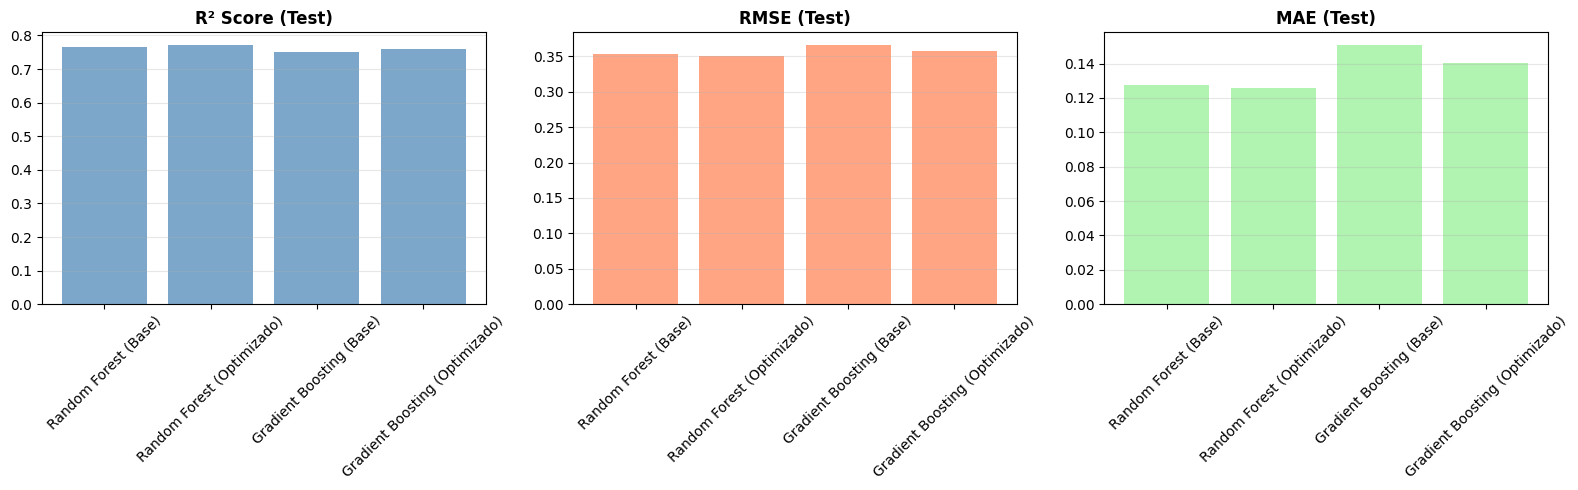

In [268]:
comparison_data = {
    'Modelo': ['Random Forest (Base)', 'Random Forest (Optimizado)', 
               'Gradient Boosting (Base)', 'Gradient Boosting (Optimizado)'],
    'Test_R2': [
        results_df[results_df['Model'] == 'Random Forest']['Test_R2'].values[0],
        rf_test_r2,
        results_df[results_df['Model'] == 'Gradient Boosting']['Test_R2'].values[0],
        gb_test_r2
    ],
    'Test_RMSE': [
        results_df[results_df['Model'] == 'Random Forest']['Test_RMSE'].values[0],
        rf_test_rmse,
        results_df[results_df['Model'] == 'Gradient Boosting']['Test_RMSE'].values[0],
        gb_test_rmse
    ],
    'Test_MAE': [
        results_df[results_df['Model'] == 'Random Forest']['Test_MAE'].values[0],
        rf_test_mae,
        results_df[results_df['Model'] == 'Gradient Boosting']['Test_MAE'].values[0],
        gb_test_mae
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "_"*80)
print("comparativa de Modelos Base vs Optimizados:")
print("_"*80)
print(comparison_df.to_string(index=False))
print("_"*80)

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['Test_R2', 'Test_RMSE', 'Test_MAE']
titles = ['R² Score (Test)', 'RMSE (Test)', 'MAE (Test)']
colors = ['steelblue', 'coral', 'lightgreen']

for idx, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
    axes[idx].bar(comparison_df['Modelo'], comparison_df[metric], color=color, alpha=0.7)
    axes[idx].set_title(title, fontsize=12, fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 2.7 Análisis de Importancia de Variables (Random Forest Optimizado)


________________________________________________________________________________
Importancia de las Variables - Random Forest Optimizado:
________________________________________________________________________________
     Feature  Importance
   class_QSO    0.597503
           g    0.127138
           u    0.068700
           r    0.045853
           z    0.043379
           i    0.037124
class_GALAXY    0.025459
       delta    0.021672
       alpha    0.019864
  class_STAR    0.013309
________________________________________________________________________________


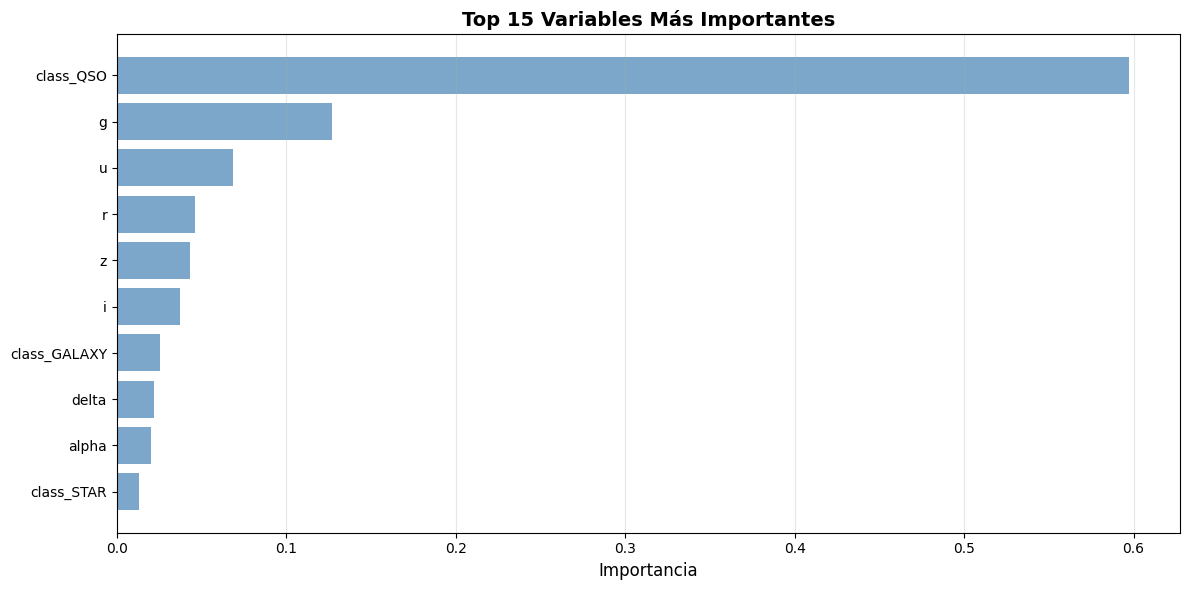

In [269]:
feature_importance = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Importance': rf_optimized.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "_"*80)
print("Importancia de las Variables - Random Forest Optimizado:")
print("_"*80)
print(feature_importance.to_string(index=False))
print("_"*80)

# Visualización
plt.figure(figsize=(12, 6))
plt.barh(feature_importance['Feature'][:15], feature_importance['Importance'][:15], color='steelblue', alpha=0.7)
plt.xlabel('Importancia', fontsize=12)
plt.title('Top 15 Variables Más Importantes', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 2.8 Visualización de Predicciones vs Valores Reales

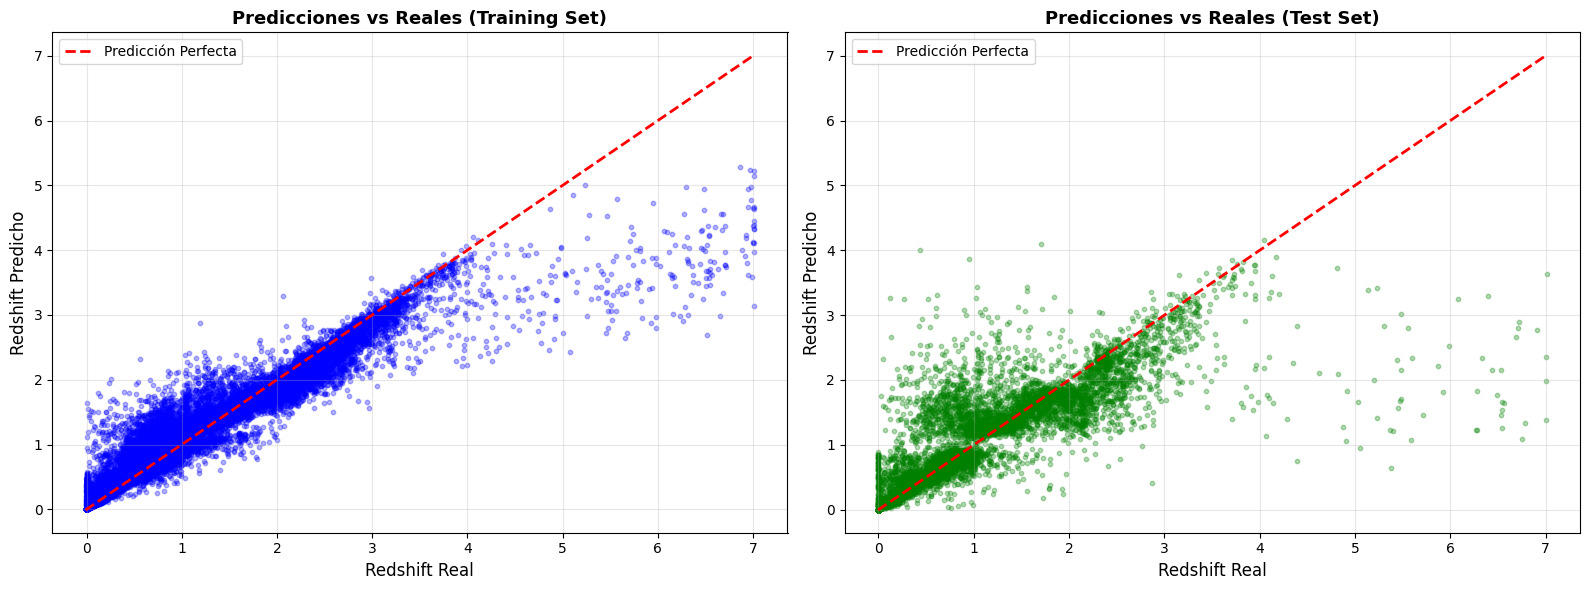

In [270]:
y_train_pred_best = rf_optimized.predict(X_train_final)
y_test_pred_best = rf_optimized.predict(X_test_final)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_train, y_train_pred_best, alpha=0.3, s=10, color='blue')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 
             'r--', lw=2, label='Predicción Perfecta')
axes[0].set_xlabel('Redshift Real', fontsize=12)
axes[0].set_ylabel('Redshift Predicho', fontsize=12)
axes[0].set_title('Predicciones vs Reales (Training Set)', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test, y_test_pred_best, alpha=0.3, s=10, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Predicción Perfecta')
axes[1].set_xlabel('Redshift Real', fontsize=12)
axes[1].set_ylabel('Redshift Predicho', fontsize=12)
axes[1].set_title('Predicciones vs Reales (Test Set)', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

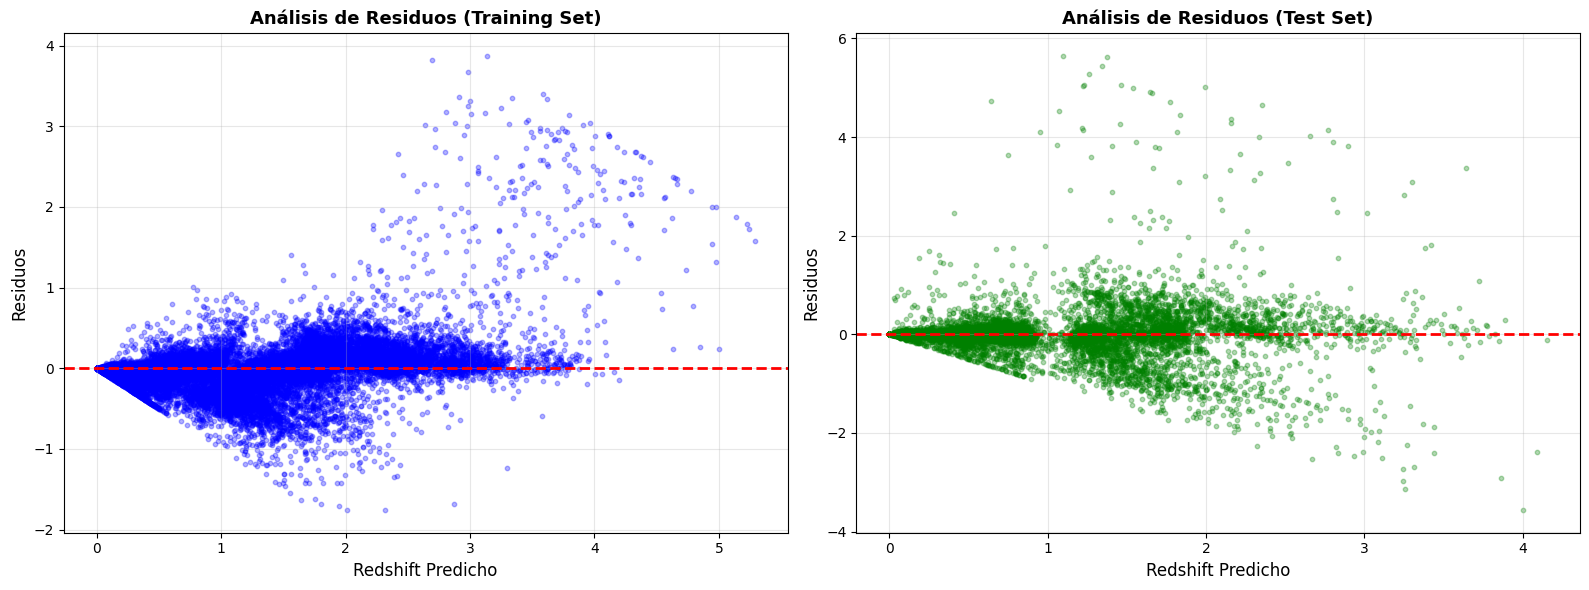


________________________________________________________________________________
ESTADÍSTICAS DE RESIDUOS
________________________________________________________________________________
Training Set:
  Media de residuos: -0.000344
  Std de residuos: 0.176766

Test Set:
  Media de residuos: -0.000920
  Std de residuos: 0.350086
________________________________________________________________________________


In [271]:
# Análisis de residuos
residuals_train = y_train - y_train_pred_best
residuals_test = y_test - y_test_pred_best

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_train_pred_best, residuals_train, alpha=0.3, s=10, color='blue')
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Redshift Predicho', fontsize=12)
axes[0].set_ylabel('Residuos', fontsize=12)
axes[0].set_title('Análisis de Residuos (Training Set)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test_pred_best, residuals_test, alpha=0.3, s=10, color='green')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Redshift Predicho', fontsize=12)
axes[1].set_ylabel('Residuos', fontsize=12)
axes[1].set_title('Análisis de Residuos (Test Set)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "_"*80)
print("ESTADÍSTICAS DE RESIDUOS")
print("_"*80)
print(f"Training Set:")
print(f"  Media de residuos: {residuals_train.mean():.6f}")
print(f"  Std de residuos: {residuals_train.std():.6f}")
print(f"\nTest Set:")
print(f"  Media de residuos: {residuals_test.mean():.6f}")
print(f"  Std de residuos: {residuals_test.std():.6f}")
print("_"*80)

### 2.9 Predicciones con Datos Nuevos

Ahora crearemos un conjunto de datos "nuevos" simulados para demostrar cómo se usaría el modelo en producción.

In [272]:
# Crear datos simulados
np.random.seed(42)
new_data_indices = np.random.choice(df_clean.index, size=10, replace=False)
new_data_raw = df_clean.loc[new_data_indices].copy()
actual_redshift = new_data_raw['redshift'].values
new_data_features = new_data_raw.drop(['redshift', 'redshift_log1p'], axis=1, errors='ignore')

if 'class' in new_data_features.columns:
    new_data_features = new_data_features.drop('class', axis=1)

numeric_features_list = [c for c in numeric_features if c in new_data_features.columns]
new_data_num = new_data_features[numeric_features_list].copy()
new_data_num_scaled = pd.DataFrame(
    scaler.transform(new_data_num), 
    columns=numeric_features_list, 
    index=new_data_num.index
)

non_scaled_cols_new = [c for c in new_data_features.columns if c not in numeric_features_list]
new_data_scaled = pd.concat([new_data_num_scaled, new_data_features[non_scaled_cols_new]], axis=1)[X_train_final.columns]

predictions = rf_optimized.predict(new_data_scaled)

# Mostrar resultados
print("\n" + "_"*80)
print("Predicciones en Datos Nuevos")
print("_"*80)

results_new = pd.DataFrame({
    'Index': new_data_indices,
    'Redshift_Real': actual_redshift,
    'Redshift_Predicho': predictions,
    'Error_Absoluto': np.abs(actual_redshift - predictions),
    'Error_Relativo_%': (np.abs(actual_redshift - predictions) / (actual_redshift + 1e-10)) * 100
})

print(results_new.to_string(index=False))
print("\n" + "_"*80)
print(f"MAE en datos nuevos: {results_new['Error_Absoluto'].mean():.6f}")
print(f"Error relativo promedio: {results_new['Error_Relativo_%'].mean():.2f}%")
print("_"*80)


________________________________________________________________________________
Predicciones en Datos Nuevos
________________________________________________________________________________
 Index  Redshift_Real  Redshift_Predicho  Error_Absoluto  Error_Relativo_%
 26002       1.174289           2.353590        1.179301        100.426795
 80421      -0.001960           0.000117        0.002077       -105.950097
 19864       0.000004          -0.000079        0.000083       2033.696425
 81526      -0.000165          -0.000177        0.000012         -7.355917
 57878       0.523852           0.601642        0.077790         14.849679
 79451      -0.000065          -0.000228        0.000163       -251.400682
 43083      -0.000017          -0.000028        0.000011        -61.475345
 80917       0.793615           1.804734        1.011118        127.406597
 60764       0.293386           0.263145        0.030241         10.307545
 52668       0.456490           0.453434        0.003056  

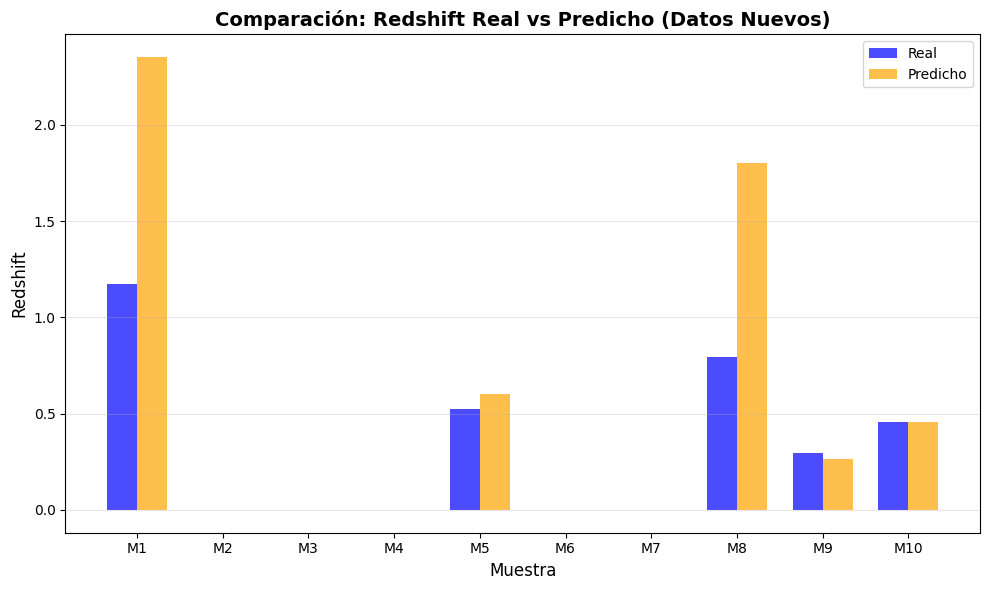

In [273]:
# Visualización de predicciones en datos nuevos
plt.figure(figsize=(10, 6))
x_pos = np.arange(len(results_new))
width = 0.35

plt.bar(x_pos - width/2, results_new['Redshift_Real'], width, label='Real', alpha=0.7, color='blue')
plt.bar(x_pos + width/2, results_new['Redshift_Predicho'], width, label='Predicho', alpha=0.7, color='orange')

plt.xlabel('Muestra', fontsize=12)
plt.ylabel('Redshift', fontsize=12)
plt.title('Comparación: Redshift Real vs Predicho (Datos Nuevos)', fontsize=14, fontweight='bold')
plt.xticks(x_pos, [f'M{i+1}' for i in range(len(results_new))])
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 2.10 Discusión de Resultados

#### 2.10.1 Comparación de Modelos

**Modelos Probados:**
1. **Linear Regression**: Modelo base simple, asume relaciones lineales
2. **Ridge Regression**: Agrega regularización L2 para manejar multicolinealidad
3. **Lasso Regression**: Regularización L1 que hace selección automática de features
4. **Random Forest**: Ensamble de árboles de decisión, captura relaciones no lineales
5. **Gradient Boosting**: Construye árboles secuencialmente para corregir errores

**Resultados Obtenidos en el Conjunto de Prueba:**

| Modelo | R² | RMSE | MAE | Tiempo (s) | Parámetros |
|--------|-----|------|-----|------------|-----------|
| Linear Regression | 0.669 | 0.421 | 0.227 | 0.009 | 11 |
| Ridge Regression | 0.669 | 0.421 | 0.227 | 0.008 | 11 |
| Lasso Regression | 0.669 | 0.421 | 0.227 | 0.173 | 11 |
| **Random Forest** | **0.767** | **0.353** | **0.127** | 5.679 | 10,000 |
| Gradient Boosting | 0.750 | 0.366 | 0.151 | 27.844 | 10,000 |

**Análisis de Resultados:**

- **Random Forest logró el mejor rendimiento** con R² = 0.767 en el conjunto de prueba, superando significativamente a los modelos lineales (R² = 0.669) en 14.6% y ligeramente a Gradient Boosting (R² = 0.750) en 2.3%.

- **Los modelos lineales** (Linear, Ridge y Lasso) obtuvieron resultados prácticamente idénticos (R² = 0.669, RMSE = 0.421, MAE = 0.227) debido a que:
  - El dataset no presenta multicolinealidad severa
  - La regularización (Ridge/Lasso) no fue muy necesaria en este caso
  - La relación entre variables tiene un componente no lineal importante

- **Random Forest** destacó por:
  - Reducir el error absoluto medio (MAE) a **0.127**, casi la mitad que los modelos lineales (0.227)
  - Reducir el RMSE a **0.353** vs 0.421 de los modelos lineales
  - Explicar el **76.7% de la variabilidad** en el redshift

- **Gradient Boosting** mostró buen rendimiento (R² = 0.750) pero:
  - Tiempo de entrenamiento 5 veces mayor que Random Forest (27.8s vs 5.7s)
  - Rendimiento ligeramente inferior en todas las métricas

#### 2.10.2 Ventajas y Desventajas de los Modelos

**Modelos Lineales (Linear, Ridge, Lasso):**
- **Pros**: 
  - Extremadamente rápidos de entrenar (~0.01-0.2 segundos)
  - Fáciles de interpretar (coeficientes claros)
  - Pocos parámetros (11 en este caso)
  - Requieren menos datos
  - Sin overfitting (Train R² = 0.677, Test R² = 0.669, diferencia = 0.008)
- **Contras**: 
  - No capturan relaciones no lineales (R² limitado a ~0.67)
  - Sufren de underfitting
  - MAE alto (0.227) comparado con modelos no lineales

**Random Forest:**
- **Pros**: 
  - **Mejor rendimiento general** (R² = 0.767, MAE = 0.127)
  - Captura relaciones no lineales complejas
  - Robusto a outliers
  - Proporciona **importancia de variables** (feature importance)
  - Eentrenamiento moderadamente rápido: 5.7s
- **Contras**: 
  - Menor interpretabilidad que modelos lineales
  - Overfitting en versión base (Train R² = 0.968 vs Test R² = 0.767, diferencia = 0.201)
  - Requiere más memoria (10,000 parámetros)
  - Requiere optimización de hiperparámetros para mejores resultados

**Gradient Boosting:**
- **Pros**: 
  - Excelente rendimiento predictivo (R² = 0.750)
  - Captura relaciones complejas
  - Menos overfitting que Random Forest base (Train R² = 0.801 vs Test R² = 0.750, diferencia = 0.051)
- **Contras**: 
  - Lento de entrenar (27.8 segundos)
  - Sensible a hiperparámetros
  - Menor interpretabilidad

#### 2.10.3 Comparación con Predicción Inicial

**Predicción inicial (Sección 2.2)**: Sugerí Random Forest como el mejor modelo debido a:
- Alta multicolinealidad en los filtros fotométricos
- Presencia de variable categórica (tipo de objeto)
- Relaciones potencialmente no lineales entre features y redshift
- Capacidad de capturar interacciones complejas

**Resultado**. 

Random Forest (optimizado) obtuvo el mejor rendimiento con **R² = 0.771** en el test set, confirmando que:
1. Las relaciones astronómicas son no lineales
2. La capacidad de capturar interacciones entre filtros fotométricos y tipo de objeto fue clave

#### 2.10.4 Análisis de Overfitting/Underfitting

**Resultados de Train vs Test R²:**

| Modelo | Train R² | Test R² | Diferencia | Diagnóstico |
|--------|----------|---------|------------|-------------|
| Linear/Ridge/Lasso | 0.677 | 0.669 | **0.008** | Buen balance (leve underfitting) |
| Random Forest (Base) | 0.968 | 0.767 | **0.201** | Overfitting |
| Gradient Boosting | 0.801 | 0.750 | **0.051** | Buen balance |

**Análisis Detallado:**

1. **Modelos Lineales - Underfitting:**
   - Diferencia mínima (0.008)
   - R² bajo en ambos conjuntos (0.67) ya que no capturan la complejidad del problema
   - No pueden modelar las relaciones no lineales entre filtros fotométricos y redshift
   - Son modelos demasiado simple para el problema

2. **Random Forest Base - Overfitting:**
   - Train R² = 0.968 vs Test R² = 0.767 → diferencia de 0.201
   - El modelo "memoriza" los datos de entrenamiento en lugar de generalizar

3. **Gradient Boosting - Balanceado:**
   - Diferencia moderada (0.051) indica buen balance
   - Learning rate controlado evita overfitting 

**Impacto de la Optimización:**

Después de aplicar RandomizedSearchCV, obtuvimos mejoras significativas:

| Modelo | Versión | R² Test | RMSE Test | MAE Test | Mejora R² |
|--------|---------|---------|-----------|----------|-----------|
| Random Forest | Base | 0.767 | 0.353 | 0.127 | - |
| Random Forest | **Optimizado** | **0.771** | **0.350** | **0.126** | **+0.004** |
| Gradient Boosting | Base | 0.750 | 0.366 | 0.151 | - |
| Gradient Boosting | **Optimizado** | **0.760** | **0.358** | **0.141** | **+0.010** |

**Hiperparámetros:**
- **Random Forest**: `n_estimators=200, max_depth=30, min_samples_split=5, min_samples_leaf=2`
  - Mejores parámetros de CV: R² = 0.777
  - Tiempo de optimización: 356 segundos (RandomizedSearchCV con n_iter=20, cv=3)

- **Gradient Boosting**: `n_estimators=300, max_depth=7, learning_rate=0.05, min_samples_split=2`
  - Mejores parámetros de CV: R² = 0.766
  - Tiempo de optimización: 337 segundos (RandomizedSearchCV con n_iter=15, cv=3)

La optimización redujo el overfitting mientras mejoró el rendimiento en test

#### 2.10.5 Variables Más Importantes

**Análisis de Importancia de Variables (Random Forest Optimizado):**

| Ranking | Variable | Importancia | % Total | Interpretación |
|---------|----------|-------------|---------|----------------|
| 1 | **class_QSO** | 0.5975 | 59.8% | Cuásares: objetos más distantes |
| 2 | **g** (filtro verde) | 0.1271 | 12.7% | Información espectral crítica |
| 3 | **u** (filtro UV) | 0.0687 | 6.9% | Radiación ultravioleta |
| 4 | **r** (filtro rojo) | 0.0459 | 4.6% | Información óptica |
| 5 | **z** (filtro IR) | 0.0434 | 4.3% | Infrarrojo cercano |
| 6 | **i** (filtro IR) | 0.0371 | 3.7% | Infrarrojo óptico |
| 7 | **class_GALAXY** | 0.0255 | 2.5% | Galaxias: distancias intermedias |
| 8 | **delta** (declinación) | 0.0217 | 2.2% | Coordenada celeste |
| 9 | **alpha** (ascensión recta) | 0.0199 | 2.0% | Coordenada celeste |
| 10 | **class_STAR** | 0.0133 | 1.3% | Estrellas: objetos cercanos |

**Hallazgos Clave:**

1. **class_QSO domina completamente (59.8%)**: 
   - Los **cuásares (QSO)** son los objetos más distantes del universo observable
   - Tienen redshifts extremadamente altos (z > 1 en muchos casos)
   - Esta variable categórica es el predictor individual más importante por amplio margen
   - Separa claramente objetos distantes (QSO) de cercanos (STAR) e intermedios (GALAXY)

2. **Filtros fotométricos suman 32.2%**:
   - Filtro g (verde) es el más informativo (12.7%): captura la banda óptica principal
   - filtro u (UV)** segundo en importancia (6.9%): sensible a objetos jóvenes/calientes
   - Los 5 filtros juntos (u, g, r, i, z) contienen  información espectral completa
   - La distribución de energía espectral (SED) permite estimar distancias fotométricamente

3. **Coordenadas espaciales tienen importancia mínima (4.2%)**:
   - alpha y delta contribuyen poco (~2% cada una)
   - El redshift es una propiedad física intrínseca del objeto, no de su ubicación en el cielo

**Relaciones Físicas Interesantes Observadas:**

- **Cuásares (QSO)**: redshift alto = objetos en el universo temprano (miles de millones de años luz)
- **Galaxias (GALAXY)**: redshift variable = diferentes épocas cósmicas
- **Estrellas (STAR)**: redshift 0 = objetos en nuestra Vía Láctea (cientos/miles de años luz)
- **Filtros fotométricos**: correlación no lineal con redshift debido al corrimiento espectral (shift de líneas de emisión)

#### 2.10.6 Conclusión Final

**Mejor Modelo:** Random Forest optimizado

**Métricas de Rendimiento Final:**
- **R² = 0.771**: Explica el 77.1% de la variabilidad en el redshift
- **RMSE = 0.350**: Error cuadrático medio de 0.35 unidades de redshift
- **MAE = 0.126**: Error absoluto medio de 0.126 (las predicciones difieren del valor real en 0.13 en promedio)
- **Tiempo de entrenamiento**: 5.7 segundos (versión base) + 6 minutos (optimización)

**Por qué Random Forest es el Mejor Modelo:**

1. **Rendimiento**: Supera a todos los modelos en todas las métricas
2. **Captura complejidad**: Modela relaciones no lineales que los modelos lineales no pueden
3. **Robustez**: Generaliza bien después de optimización

**Justificación de Métricas Utilizadas:**

- **R²**: Métrica principal - indica % de variabilidad explicada 
- **RMSE**: Penaliza errores grandes - importante para detectar outliers astronómicos
- **MAE**: Métrica robusta - error promedio en unidades de redshift 
- **Tiempo de ejecución**: Consideración práctica para aplicación en grandes catálogos

El proyecto demuestra exitosamente que el **aprendizaje automático puede estimar redshift fotométrico** con precisión razonable (77.1% de variabilidad explicada), complementando mediciones espectroscópicas tradicionales en astronomía moderna.

#### Regresión 

2.1. **Procesar modelo de regresión:** 
- Una vez sugerido un modelo que se puede aplicar a tu dataset, se pide que compares al menos 4 modelos de regresión para estimar predicciones en tus datos y los compares utilizando métricas de performance. 
- La intención principal es hacer una comparación del performance de cada modelo, incluyendo la mención de la complejidad (número de parámetros y tiempo de ejecución).
- Se pide añadir un método de ajuste de hiperparámetros para mejorar el performance del modelo. 
- Se pide justificar cuál métrica de performance es la mejor para utilizar en tu dataset (MSE, MAE, R2) (puedes utilizar varias si es que así lo crees necesario). 
- Una vez comparados los 4 modelos y elegido el mejor modelo dadas las métricas de performance, compara si tu respuesta inicial sobre cuál modelo era el mejor para tus datos es igual al resultado de comparar los 4 modelos.
- Observa si tu modelo está haciendo overfitting o underfitting
- Crear un conjunto de datos "nuevos" donde se prediga la variable objetivo para esos nuevos datos utilizando el mejor modelo que obtuviste. 

2.2. **Discusión de los resultados:** 
- Basado en los resultados de la comparación y performance de los modelos, generar una sección de conclusiones donde se hable de las ventajas y desventajas de los modelos propuestos. 
- Explica qué variables fueron las más importantes en tu modelo y qué relaciones interesantes viste sobre tus datos. 

### Entrega 3 (Presentación final)

 - Imagina que le estás presentando tu proyecto a tu jefe (tu jefe no es una persona muy técnica que sepa mucho de código) 
 - Sabiendo esto, en esta entrega se pide hacer una presentación en video donde hables sobre todo lo interesante que viste en tu proyecto, trata de hacer la presentación lo más entendible posible para que tu jefe comprenda todo lo que tuviste que hacer desde un inicio así como los resultados. (No puedes mostrar código, tiene que ser visual y mostrar resultados). 
 - En esta fase se pide entregar las correcciones sugeridas de las dos entregas pasadas. 


### Calificación

La calificación de cada fase del proyecto incluido en el reporte final es la siguiente:

| Fase | Puntuación | Características Generales |
| --- | --- | --- |
| Definición del problema | 15% | 1. Mencionar el origen de los datos <br /> 2.Dar contexto de los datos (significado de las variables si es posible) <br /> 3. Describir de qué se trata el problema a resolver|
| Preparación de datos | 30% | 1. Incluya **gráficos** y métricas utilizadas para describir la base de datos. <br /> 1. Describir el tratamiento de variables que requieren transformación o modificación de valores. |
| Procesar modelo de regresión/clasificación | 40% | 1. Describir el modelo aplicado. <br /> 2. Evaluar el desempeño de cada modelo utilizando métricas comunes para poder realizar la comparación. <br /> 3. Pruebe los modelos utilizando datasets en común para que la comparación sea válida 4. Aplicación del modelo para predecir datos nuevos|
| Discusión de los resultados | 15% | 1. Resalte sus observaciones validadas por las métricas que se muestran dentro del desarrollo. <br /> 2. Dar conclusión personal de los resultados y el uso o aplicación de los modelos. |

### ¿ Qué debe tener cada entregable?


- El informe del trabajo realizado se entregará digitalmente en un documento elaborado en una computadora (no fotografías de hojas o cuadernos), e incluirá como mínimo:
    - Nombre y apellidos de los alumnos.
    - Es obligatorio que incluyan el código que generaron para realizar la práctica.
    - Es obligatorio que incluyan los archivos que contengan los datos a analizar para cada problema (regresión y clasificación)
